In [2]:
"""
╔══════════════════════════════════════════════════════════════╗
║  THE NAVIGATORS — Lead Spring CRM Capstone 2026              ║
║  Complete EDA Notebook — Tested Against Real ABS Files       ║
║  8165DC01.xlsx | 8165DC02.xlsx | 81290DO001_201516.xls       ║
╚══════════════════════════════════════════════════════════════╝
"""

'\n╔══════════════════════════════════════════════════════════════╗\n║  THE NAVIGATORS — Lead Spring CRM Capstone 2026              ║\n║  Complete EDA Notebook — Tested Against Real ABS Files       ║\n║  8165DC01.xlsx | 8165DC02.xlsx | 81290DO001_201516.xls       ║\n╚══════════════════════════════════════════════════════════════╝\n'

In [1]:
# CELL 1 — Install libraries

!pip install openpyxl xlrd seaborn scikit-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 120,
})

CYAN="#2BBCD4"; NAVY="#0F3460"; GREEN="#1D9E75"
AMBER="#EF9F27"; RED="#E24B4A"; GRAY="#B4B2A9"

print(" Cell 1 done — libraries ready")

 Cell 1 done — libraries ready


In [3]:
# CELL 2 — Upload the 3 ABS files
from google.colab import files
print("Upload: 8165DC01.xlsx  |  8165DC02.xlsx  |  81290do001_201516.xls")
uploaded = files.upload()
for fn in uploaded:
    print(f"  {fn}")

print("\n Cell 2 done — files uploaded")

Upload: 8165DC01.xlsx  |  8165DC02.xlsx  |  81290do001_201516.xls


Saving 8165DC01.xlsx to 8165DC01.xlsx
Saving 8165DC02.xlsx to 8165DC02.xlsx
Saving 81290do001_201516-2.xls to 81290do001_201516-2.xls
  8165DC01.xlsx
  8165DC02.xlsx
  81290do001_201516-2.xls

 Cell 2 done — files uploaded


In [5]:
# CELL 3 — Parse Table 1: Industry counts 2021-2025

YEARS  = {"2021-22","2022-23","2023-24","2024-25"}
STATES = {"New South Wales","Victoria","Queensland","South Australia",
          "Western Australia","Tasmania","Northern Territory",
          "Australian Capital Territory","Australia"}

raw = pd.read_excel("8165DC01.xlsx", sheet_name="Table 1",
                    header=None, engine="openpyxl")
rows=[]; yr=None
for _, row in raw.iterrows():
    v0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if v0 in YEARS:
        yr = v0
        continue
    if yr and v0 and v0 != "nan":
        try:
            float(row.iloc[1])
            rows.append([yr, v0] + list(row.iloc[1:].values))
        except (ValueError, TypeError):
            pass

df_ind = pd.DataFrame(rows, columns=[
    "Year","Industry","Op_Start","Entries_Births","Entries_Other",
    "Entries_Total","Exits_Cancel","Exits_Other","Exits_Total",
    "Op_End","Change","Pct_Change","Entry_Rate","Exit_Rate"])
df_ind = df_ind[
    ~df_ind["Industry"].str.contains("Currently Unknown", na=False)
].reset_index(drop=True)
for c in df_ind.columns[2:]:
    df_ind[c] = pd.to_numeric(df_ind[c], errors="coerce")

print(f" Table 1 — {len(df_ind)} rows | {df_ind['Year'].nunique()} years "
      f"| {df_ind['Industry'].nunique()} industries")
print(df_ind[df_ind["Year"]=="2024-25"][
    ["Industry","Op_End","Pct_Change"]].head(5).to_string(index=False))


 Table 1 — 81 rows | 4 years | 21 industries
                                  Industry   Op_End  Pct_Change
         Agriculture, Forestry and Fishing 170890.0        -0.8
                                    Mining   8663.0         0.9
                             Manufacturing  90663.0         0.2
Electricity, Gas, Water and Waste Services   8870.0         1.0
                              Construction 462939.0         2.2


In [7]:
# CELL 4 — Table 4: State counts (14 cols — has Net_Movement)

raw4 = pd.read_excel("8165DC01.xlsx", sheet_name="Table 4",
                     header=None, engine="openpyxl")
rows4=[]; yr4=None
for _, row in raw4.iterrows():
    v0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if v0 in YEARS:
        yr4 = v0
        continue
    if yr4 and v0 in STATES:
        try:
            float(row.iloc[1])
            rows4.append([yr4, v0] + list(row.iloc[1:].values))
        except (ValueError, TypeError):
            pass

df_state = pd.DataFrame(rows4, columns=[
    "Year","State","Op_Start","Entries_Births","Entries_Other",
    "Entries_Total","Exits_Cancel","Exits_Other","Exits_Total",
    "Net_Movement","Op_End","Change","Pct_Change","Entry_Rate","Exit_Rate"])
for c in df_state.columns[2:]:
    df_state[c] = pd.to_numeric(df_state[c], errors="coerce")
df_state = df_state.reset_index(drop=True)

wa = df_state[df_state["State"]=="Western Australia"][
    ["Year","Op_End","Change","Pct_Change","Entry_Rate"]].reset_index(drop=True)
print(f" Table 4 — {len(df_state)} rows | WA summary:")
print(wa.to_string(index=False))

 Table 4 — 36 rows | WA summary:
   Year  Op_End  Change  Pct_Change  Entry_Rate
2021-22  239853    9614         4.2        16.6
2022-23  246689    6836         2.9        15.6
2023-24  255396    8707         3.5        16.6
2024-25  266273   10877         4.3        17.1


In [8]:
# CELL 5 — Parse Tables 2 & 5: Survival rates (10 cols each)

# Table 2 — survival by industry
raw2 = pd.read_excel("8165DC01.xlsx", sheet_name="Table 2",
                     header=None, engine="openpyxl")
rows2=[]
for _, row in raw2.iterrows():
    v0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if v0 and "Commonwealth" not in v0 and "©" not in v0 and v0 != "nan":
        try:
            float(row.iloc[1])
            rows2.append(list(row.iloc[:10].values))
        except (ValueError, TypeError):
            pass

df_surv_ind = pd.DataFrame(rows2, columns=[
    "Industry","Op_June2021","Surv_June2022","Rate_2022",
    "Surv_June2023","Rate_2023","Surv_June2024","Rate_2024",
    "Surv_June2025","Rate_2025"])
df_surv_ind = df_surv_ind[
    ~df_surv_ind["Industry"].str.contains("Currently Unknown", na=False)
].reset_index(drop=True)
for c in df_surv_ind.columns[1:]:
    df_surv_ind[c] = pd.to_numeric(df_surv_ind[c], errors="coerce")

# Table 5 — survival by state
raw5 = pd.read_excel("8165DC01.xlsx", sheet_name="Table 5",
                     header=None, engine="openpyxl")
rows5=[]
for _, row in raw5.iterrows():
    v0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if v0 in STATES:
        try:
            float(row.iloc[1])
            rows5.append(list(row.iloc[:10].values))
        except (ValueError, TypeError):
            pass

df_surv_state = pd.DataFrame(rows5, columns=[
    "State","Op_June2021","Surv_June2022","Rate_2022",
    "Surv_June2023","Rate_2023","Surv_June2024","Rate_2024",
    "Surv_June2025","Rate_2025"])
for c in df_surv_state.columns[1:]:
    df_surv_state[c] = pd.to_numeric(df_surv_state[c], errors="coerce")
df_surv_state = df_surv_state.reset_index(drop=True)

wa_sv = df_surv_state[df_surv_state["State"]=="Western Australia"].iloc[0]
print(f" Table 2 — {len(df_surv_ind)} industry rows")
print(f" Table 5 — {len(df_surv_state)} state rows")
print(f"   WA 4-year survival : {wa_sv['Rate_2025']}%")
print(f"   WA 4-year failure  : {round(100-wa_sv['Rate_2025'],1)}%")


 Table 2 — 24 industry rows
 Table 5 — 9 state rows
   WA 4-year survival : 64.1%
   WA 4-year failure  : 35.9%


In [11]:
# CELL 6 — Parse Table 13: Employment size (14 cols — has Net_Movement)

raw13 = pd.read_excel("8165DC01.xlsx", sheet_name="Table 13",
                      header=None, engine="openpyxl")
rows13=[]; yr13=None
for _, row in raw13.iterrows():
    v0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if v0 in YEARS:
        yr13 = v0
        continue
    if yr13 and v0 and v0 not in ("nan","Employing"):
        try:
            float(row.iloc[1])
            rows13.append([yr13, v0] + list(row.iloc[1:].values))
        except (ValueError, TypeError):
            pass

df_emp = pd.DataFrame(rows13, columns=[
    "Year","Size","Op_Start","Entries_Births","Entries_Other",
    "Entries_Total","Exits_Cancel","Exits_Other","Exits_Total",
    "Net_Movement","Op_End","Change","Pct_Change","Entry_Rate","Exit_Rate"])
df_emp = df_emp[
    ~df_emp["Size"].str.contains("Total employing", na=False)
].reset_index(drop=True)
for c in df_emp.columns[2:]:
    df_emp[c] = pd.to_numeric(df_emp[c], errors="coerce")

emp_24 = df_emp[(df_emp["Year"]=="2024-25") &
                (~df_emp["Size"].str.contains("Total", na=False))]
print(f" Table 13 — {len(df_emp)} rows | 2024-25 breakdown:")
print(emp_24[["Size","Op_End"]].to_string(index=False))


 Table 13 — 25 rows | 2024-25 breakdown:
                       Size    Op_End
              Non–employing 1735470.0
                        1–4  688870.0
                       5–19  232129.0
                     20–199   67857.0
                       200+    5322.0
© Commonwealth of Australia       NaN


In [10]:

# CELL 7 — Parse 8165DC02: WA industry class detail


raw_dc = pd.read_excel("8165DC02.xlsx", sheet_name="Table 1",
                       header=None, engine="openpyxl")
dc = raw_dc.iloc[7:].copy()
dc = dc.iloc[:, :36]
dc.columns = [
    "State","ANZSIC_Code","Industry_Label",
    "OpS_Non","OpS_14","OpS_519","OpS_20199","OpS_200","OpS_Total",
    "Ent_Non","Ent_14","Ent_519","Ent_20199","Ent_200","Ent_Total",
    "Ex_Non","Ex_14","Ex_519","Ex_20199","Ex_200","Ex_Total",
    "Net_Non","Net_14","Net_519","Net_20199","Net_200","Net_Total",
    "OpE_Non","OpE_14","OpE_519","OpE_20199","OpE_200","OpE_Total",
    "Change","Pct_Change","Entry_Rate"]

df_wa = dc[dc["State"].astype(str).str.strip()=="Western Australia"
           ].copy().reset_index(drop=True)
for c in df_wa.columns[3:]:
    df_wa[c] = pd.to_numeric(df_wa[c], errors="coerce").fillna(0)

df_wa["SmBiz"]     = df_wa["OpE_Non"] + df_wa["OpE_14"] + df_wa["OpE_519"]
df_wa["SmBiz_Pct"] = np.where(
    df_wa["OpE_Total"] > 0,
    (df_wa["SmBiz"] / df_wa["OpE_Total"] * 100).round(1), 0)

def classify(code, label):
    c = str(code).strip(); l = str(label).lower()
    if c[:2] in ("30","31","32") or "construction" in l: return "Construction"
    if c[:2] in ("62","63","64") or any(k in l for k in
        ("financial","insurance","broking")):             return "Financial & Insurance"
    if c[:2] == "67" or "real estate" in l:              return "Real Estate"
    if c[:2] in ("69","70") or any(k in l for k in
        ("professional","scientific","legal","accounting",
         "consulting","engineering","computer system")):  return "Professional & IT"
    if c[:2] in ("72","73") or "administrative" in l:    return "Admin & Support"
    if c[:2] in ("80","81","82") or any(k in l for k in
        ("education","training","school")):               return "Education"
    if c[:2] in ("85","86","87") or any(k in l for k in
        ("health","medical","dental","allied","social")):  return "Health & Social"
    return "Other"

df_wa["Segment"] = df_wa.apply(
    lambda r: classify(r["ANZSIC_Code"], r["Industry_Label"]), axis=1)

LS_SEGS = ["Construction","Financial & Insurance","Real Estate",
           "Professional & IT","Admin & Support","Education","Health & Social"]

print(f"DC02 WA — {len(df_wa)} rows | businesses by segment:")
for seg, tot in df_wa.groupby("Segment")["OpE_Total"].sum().sort_values(
        ascending=False).items():
    print(f"   {seg:30} {tot:>8,.0f}")

DC02 WA — 496 rows | businesses by segment:
   Other                           110,882
   Construction                     46,597
   Professional & IT                34,124
   Real Estate                      25,399
   Health & Social                  20,551
   Financial & Insurance            13,011
   Admin & Support                  11,773
   Education                         3,928


In [12]:
# CELL 8 — Parse 81290DO001: Business IT Use 2015-16

import os
it_file = None
for f in os.listdir("."):
    if "81290" in f.lower() or ("201516" in f and f.endswith(".xls")):
        it_file = f; break
if not it_file:
    print("⚠️  IT file not found — uploading now...")
    from google.colab import files
    up = files.upload()
    it_file = list(up.keys())[0]

raw_it = pd.read_excel(it_file, sheet_name="Table_1",
                       header=None, engine="xlrd")
rows_it=[]
for _, row in raw_it.iterrows():
    v0 = str(row.iloc[0]).strip() if pd.notna(row.iloc[0]) else ""
    if v0 and "Commonwealth" not in v0 and "©" not in v0 and v0 != "nan":
        try:
            float(row.iloc[1])
            rows_it.append(list(row.iloc[:7].values))
        except (ValueError, TypeError):
            pass

df_it = pd.DataFrame(rows_it, columns=[
    "Industry","IT_Specialist_Pct","Not_IT_Spec_Pct",
    "SW_HW_Supplier_Pct","Contractor_Pct",
    "Other_Pct","No_IT_Support_Pct"])
df_it = df_it[~df_it["Industry"].str.strip().isin(["Total",""])
              ].reset_index(drop=True)
for c in df_it.columns[1:]:
    df_it[c] = pd.to_numeric(df_it[c], errors="coerce")

print(f" IT file — {len(df_it)} industry rows")
print(df_it[["Industry","Contractor_Pct"]].sort_values(
    "Contractor_Pct", ascending=False).to_string(index=False))

 IT file — 27 industry rows
                                                              Industry  Contractor_Pct
                                                   200 or more persons            69.4
                                      Financial and Insurance Services            54.8
                                                        20–199 persons            54.5
                                                                Mining            46.9
                                                          5–19 persons            39.0
                            Electricity, Gas, Water and Waste Services            38.0
                                     Health Care and Social Assistance            37.6
                                                         Manufacturing            37.5
                                                       Wholesale Trade            37.4
                       Professional, Scientific and Technical Services            37.2
               

In [13]:
# CELL 9 — DESCRIPTIVE STATISTICS — all datasets

print("="*60)
print("DESCRIPTIVE STATISTICS — ALL THREE ABS FILES")
print("="*60)

print("\n── Table 1: Industry Counts ──────────────────────────────")
print(df_ind[["Op_Start","Op_End","Change",
              "Pct_Change","Entry_Rate","Exit_Rate"]].describe().round(2))

print("\n── Table 4: State Counts ─────────────────────────────────")
print(df_state[["Op_End","Change","Pct_Change",
                 "Entry_Rate","Exit_Rate"]].describe().round(2))

print("\n── Table 2: Survival by Industry ─────────────────────────")
print(df_surv_ind[["Rate_2022","Rate_2023",
                    "Rate_2024","Rate_2025"]].describe().round(2))

print("\n── Table 5: Survival by State ────────────────────────────")
print(df_surv_state[["Rate_2022","Rate_2023",
                      "Rate_2024","Rate_2025"]].describe().round(2))

print("\n── Table 13: Employment Size ─────────────────────────────")
print(df_emp[["Op_End","Change","Pct_Change"]].describe().round(2))

print("\n── DC02: WA Industry Classes ─────────────────────────────")
print(df_wa[["OpE_Total","SmBiz_Pct",
              "Pct_Change","Entry_Rate"]].describe().round(2))

print("\n── 81290DO001: IT Use ────────────────────────────────────")
print(df_it[["IT_Specialist_Pct","Contractor_Pct",
              "No_IT_Support_Pct"]].describe().round(2))

# Key stats
wa_2425 = df_state[(df_state["State"]=="Western Australia")&
                   (df_state["Year"]=="2024-25")].iloc[0]
wa_sv   = df_surv_state[df_surv_state["State"]=="Western Australia"].iloc[0]
au_sv   = df_surv_state[df_surv_state["State"]=="Australia"].iloc[0]
hc_g    = df_ind[(df_ind["Year"]=="2024-25")&
                 (df_ind["Industry"]=="Health Care and Social Assistance")].iloc[0]
print("\n── KEY STATISTICS ────────────────────────────────────────")
print(f"  WA total businesses June 2025 : {int(wa_2425['Op_End']):,}")
print(f"  WA new entries 2024-25        : {int(wa_2425['Entries_Total']):,}")
print(f"  WA exits 2024-25              : {int(wa_2425['Exits_Total']):,}")
print(f"  WA growth rate 2024-25        : {wa_2425['Pct_Change']}%  ← fastest in Australia")
print(f"  WA 4-year survival rate       : {wa_sv['Rate_2025']}%")
print(f"  WA 4-year FAILURE rate        : {round(100-wa_sv['Rate_2025'],1)}%")
print(f"  National 4-year survival      : {au_sv['Rate_2025']}%")
print(f"  Health Care growth 2024-25    : {hc_g['Pct_Change']}%  ← highest nationally")
print(f"  Avg contractor/consult use    : {df_it['Contractor_Pct'].mean():.1f}%")
print(f"  Financial Services contractor : {df_it[df_it['Industry']=='Financial and Insurance Services']['Contractor_Pct'].values[0]}%  ← highest industry")

print("\n Cell 9 done")

DESCRIPTIVE STATISTICS — ALL THREE ABS FILES

── Table 1: Industry Counts ──────────────────────────────
         Op_Start      Op_End     Change  Pct_Change  Entry_Rate  Exit_Rate
count       80.00       80.00      80.00       80.00       80.00      80.00
mean    254771.04   262961.50    8190.46        3.01       16.80      13.79
std     541776.09   558987.12   19323.19        2.64        4.15       3.10
min       7047.00     7510.00   -2204.00       -1.30        7.20       7.80
25%      38245.25    40223.50     214.50        1.15       14.88      12.15
50%     118767.00   123496.00    2850.50        2.50       16.70      13.70
75%     197628.25   210714.75    8775.00        4.58       18.23      15.32
max    2662998.00  2729648.00  137470.00       10.00       29.20      22.10

── Table 4: State Counts ─────────────────────────────────
           Op_End     Change  Pct_Change  Entry_Rate  Exit_Rate
count       36.00      36.00       36.00       36.00      36.00
mean    584396.42   181

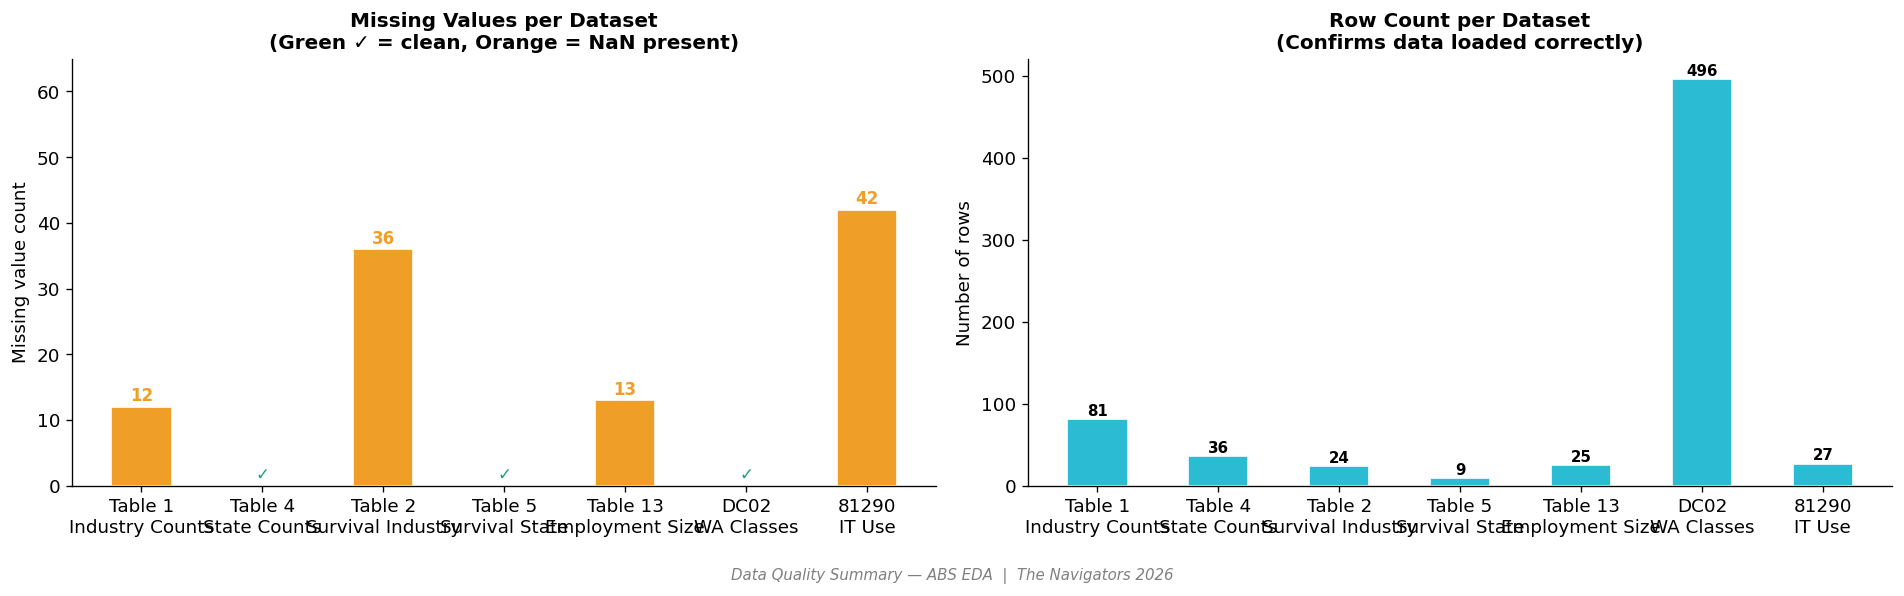

Missing value notes:
  Table 1 — NaN in Pct_Change for declining industries (expected)
  Table 2/13 — NaN for suppressed small cells (ABS rounds to 3)
  IT file — NaN where value suppressed for confidentiality

 Cell 10 done — chart_00_data_quality.png saved


In [15]:
# CELL 10 — DATA QUALITY CHECK

datasets = {
    "Table 1\nIndustry Counts":  df_ind,
    "Table 4\nState Counts":     df_state,
    "Table 2\nSurvival Industry":df_surv_ind,
    "Table 5\nSurvival State":   df_surv_state,
    "Table 13\nEmployment Size": df_emp,
    "DC02\nWA Classes":          df_wa[["ANZSIC_Code","Industry_Label",
                                         "OpE_Total","Pct_Change","Segment"]],
    "81290\nIT Use":             df_it,
}

miss = {k: int(v.isnull().sum().sum()) for k, v in datasets.items()}
rows_c = {k: len(v) for k, v in datasets.items()}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Missing values bar
bars = axes[0].bar(miss.keys(), miss.values(),
                   color=[GREEN if v==0 else AMBER for v in miss.values()],
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, miss.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3,
                 f"{val}" if val > 0 else "✓",
                 ha="center", va="bottom", fontsize=10, fontweight="bold",
                 color=GREEN if val==0 else AMBER)
axes[0].set_title("Missing Values per Dataset\n(Green ✓ = clean, Orange = NaN present)",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Missing value count")
axes[0].set_ylim(0, max(miss.values())*1.5+2)

# Row count bar
axes[1].bar(rows_c.keys(), rows_c.values(), color=CYAN,
            edgecolor="white", width=0.5)
for bar, val in zip(axes[1].patches, rows_c.values()):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+1,
                 f"{val:,}", ha="center", va="bottom",
                 fontsize=9, fontweight="bold")
axes[1].set_title("Row Count per Dataset\n(Confirms data loaded correctly)",
                  fontsize=12, fontweight="bold")
axes[1].set_ylabel("Number of rows")

plt.suptitle("Data Quality Summary — ABS EDA  |  The Navigators 2026",
             y=-0.02, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_00_data_quality.png", dpi=150, bbox_inches="tight")
plt.show()

print("Missing value notes:")
print("  Table 1 — NaN in Pct_Change for declining industries (expected)")
print("  Table 2/13 — NaN for suppressed small cells (ABS rounds to 3)")
print("  IT file — NaN where value suppressed for confidentiality")
print("\n Cell 10 done — chart_00_data_quality.png saved")


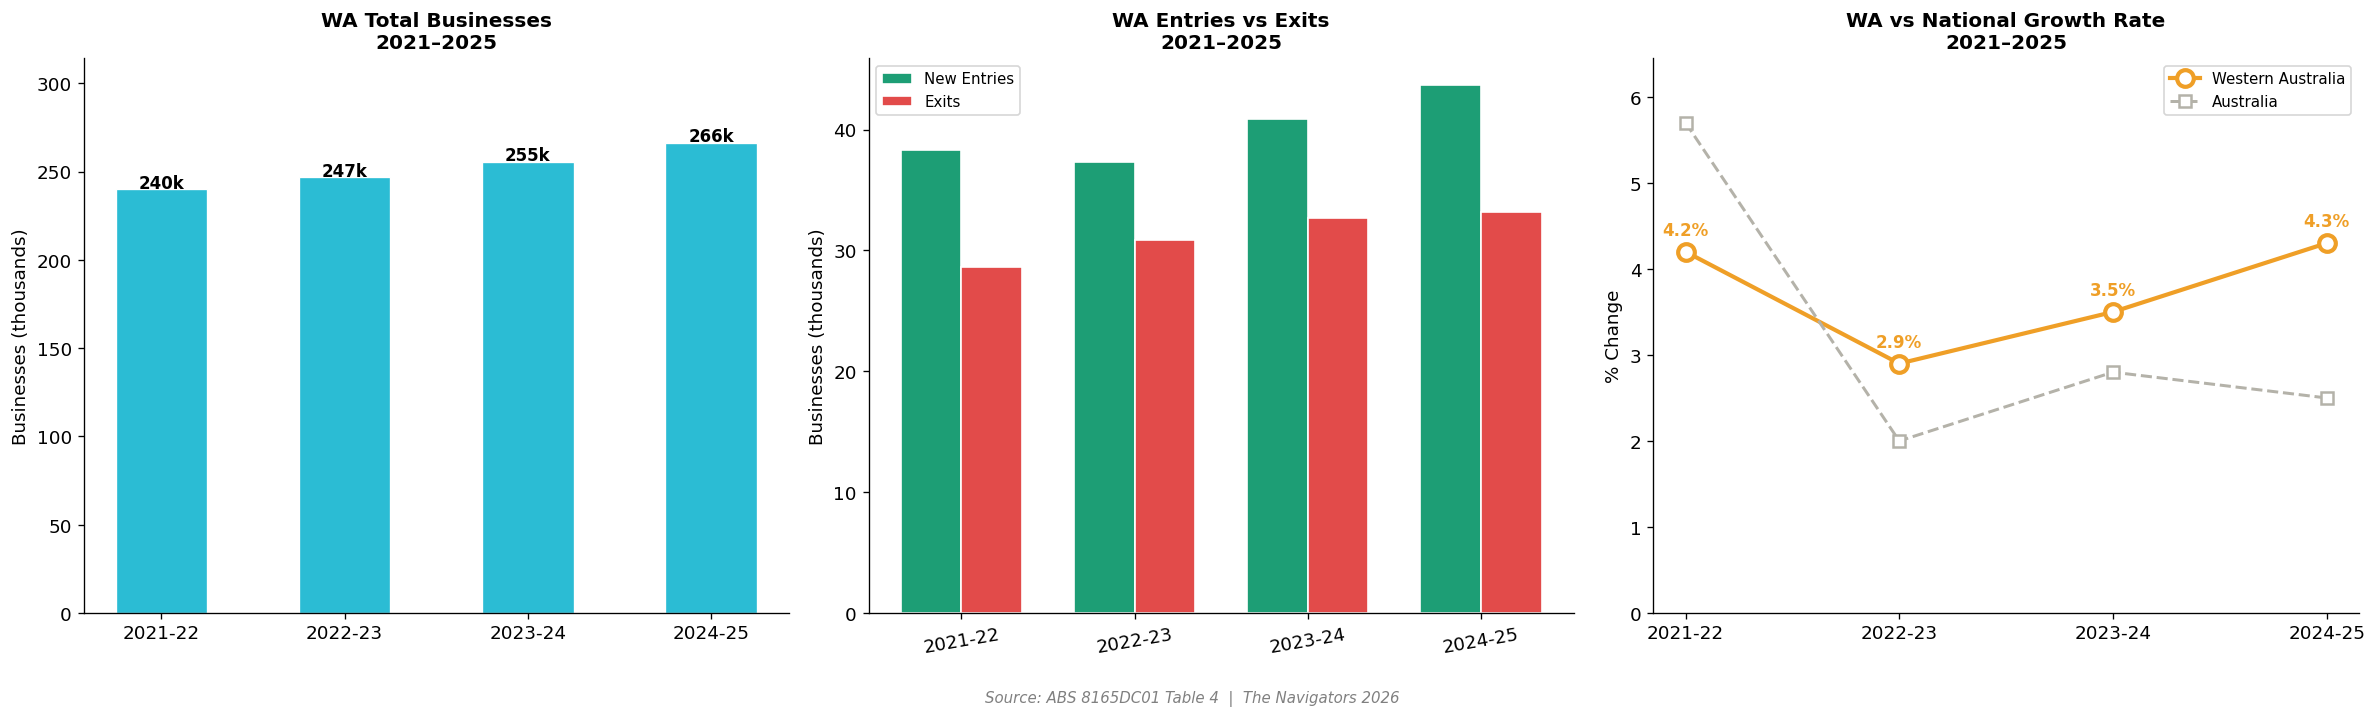

 Cell 11 done — chart_01_wa_growth.png saved


In [16]:

# CELL 11 — CHART 1: WA Business Growth Trend


wa_t = df_state[df_state["State"]=="Western Australia"].copy()
au_t = df_state[df_state["State"]=="Australia"].copy()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1a — total businesses
ax = axes[0]
bars = ax.bar(wa_t["Year"], wa_t["Op_End"]/1000,
              color=CYAN, edgecolor="white", linewidth=0.8, width=0.5)
for bar, val in zip(bars, wa_t["Op_End"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f"{val/1000:.0f}k", ha="center", fontsize=10, fontweight="bold")
ax.set_title("WA Total Businesses\n2021–2025", fontsize=12, fontweight="bold")
ax.set_ylabel("Businesses (thousands)")
ax.set_ylim(0, wa_t["Op_End"].max()/1000 * 1.18)

# 1b — entries vs exits
ax2 = axes[1]
x = np.arange(len(wa_t)); w = 0.35
ax2.bar(x-w/2, wa_t["Entries_Total"]/1000, w,
        label="New Entries", color=GREEN, edgecolor="white")
ax2.bar(x+w/2, wa_t["Exits_Total"]/1000, w,
        label="Exits", color=RED, edgecolor="white")
ax2.set_xticks(x); ax2.set_xticklabels(wa_t["Year"], rotation=10)
ax2.set_title("WA Entries vs Exits\n2021–2025", fontsize=12, fontweight="bold")
ax2.set_ylabel("Businesses (thousands)"); ax2.legend(fontsize=9)

# 1c — WA vs national growth rate
ax3 = axes[2]
ax3.plot(wa_t["Year"], wa_t["Pct_Change"],
         "o-", color=AMBER, linewidth=2.5, markersize=10,
         markerfacecolor="white", markeredgewidth=2.5, label="Western Australia")
ax3.plot(au_t["Year"], au_t["Pct_Change"],
         "s--", color=GRAY, linewidth=1.8, markersize=7,
         markerfacecolor="white", markeredgewidth=1.5, label="Australia")
for yr, val in zip(wa_t["Year"], wa_t["Pct_Change"]):
    ax3.annotate(f"{val}%", (yr, val),
                 textcoords="offset points", xytext=(0,10),
                 ha="center", fontsize=10, fontweight="bold", color=AMBER)
ax3.set_title("WA vs National Growth Rate\n2021–2025",
              fontsize=12, fontweight="bold")
ax3.set_ylabel("% Change"); ax3.legend(fontsize=9)
ax3.set_ylim(0, wa_t["Pct_Change"].max()*1.5)

plt.suptitle("Source: ABS 8165DC01 Table 4  |  The Navigators 2026",
             y=-0.02, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_01_wa_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 11 done — chart_01_wa_growth.png saved")

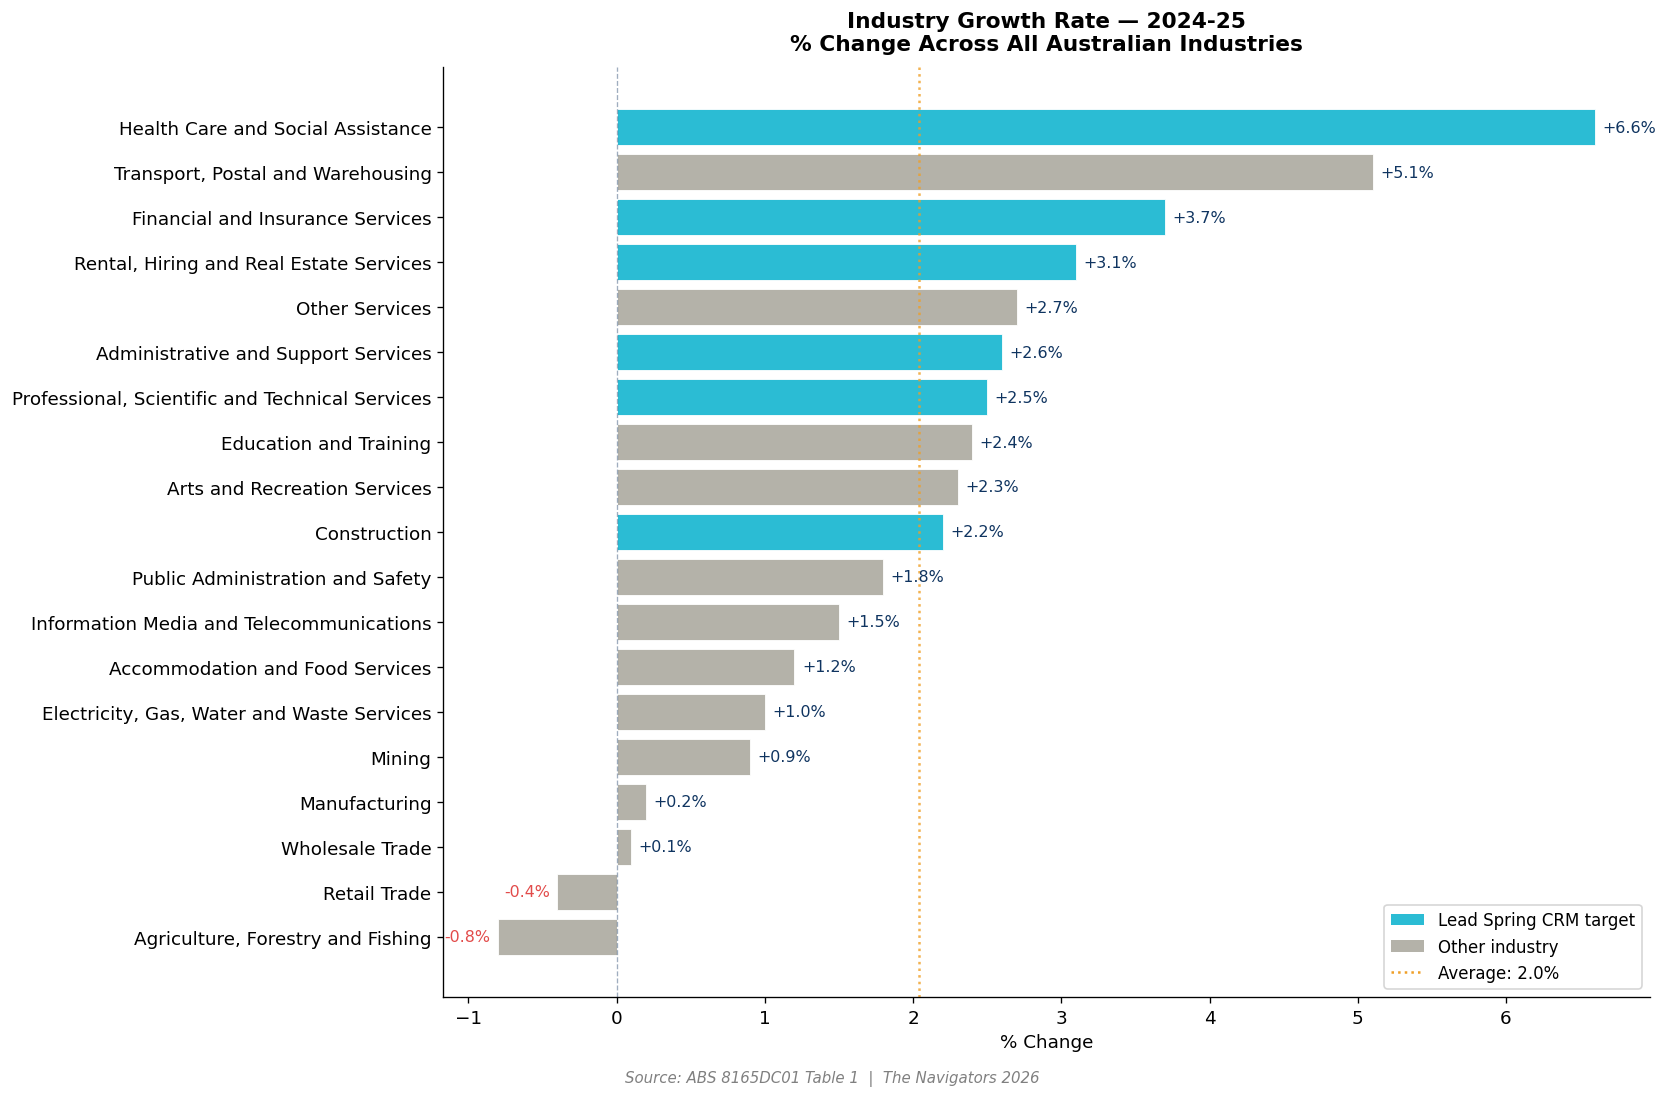

 Cell 12 done — chart_02_industry_growth.png saved


In [17]:

# CELL 12 — CHART 2: Industry Growth Rates 2024-25

LS_TARGETS = {
    "Construction","Financial and Insurance Services",
    "Professional, Scientific and Technical Services",
    "Health Care and Social Assistance",
    "Administrative and Support Services",
    "Rental, Hiring and Real Estate Services",
}

df_g = df_ind[(df_ind["Year"]=="2024-25") &
              (~df_ind["Industry"].str.contains("All Industries"))
              ].dropna(subset=["Pct_Change"]).copy()
df_g = df_g.sort_values("Pct_Change", ascending=True)
bar_colors = [CYAN if i in LS_TARGETS else GRAY for i in df_g["Industry"]]
avg_g = df_g["Pct_Change"].mean()

fig, ax = plt.subplots(figsize=(14, 9))
bars = ax.barh(df_g["Industry"], df_g["Pct_Change"],
               color=bar_colors, edgecolor="white", linewidth=0.5)
ax.axvline(0, color=NAVY, linewidth=0.8, linestyle="--", alpha=0.4)
ax.axvline(avg_g, color=AMBER, linewidth=1.5, linestyle=":",
           alpha=0.8, label=f"Average: {avg_g:.1f}%")
for bar, val in zip(bars, df_g["Pct_Change"]):
    xp = val+0.05 if val>=0 else val-0.05
    ax.text(xp, bar.get_y()+bar.get_height()/2, f"{val:+.1f}%",
            va="center", ha="left" if val>=0 else "right", fontsize=9.5,
            color=RED if val<0 else NAVY)
ax.set_title("Industry Growth Rate — 2024-25\n% Change Across All Australian Industries",
             fontsize=13, fontweight="bold", pad=10)
ax.set_xlabel("% Change")
ax.legend(handles=[Patch(facecolor=CYAN, label="Lead Spring CRM target"),
                   Patch(facecolor=GRAY, label="Other industry"),
                   plt.Line2D([0],[0], color=AMBER, linestyle=":",
                               label=f"Average: {avg_g:.1f}%")],
          loc="lower right", fontsize=10)
plt.figtext(0.5, -0.01,
            "Source: ABS 8165DC01 Table 1  |  The Navigators 2026",
            ha="center", fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_02_industry_growth.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 12 done — chart_02_industry_growth.png saved")

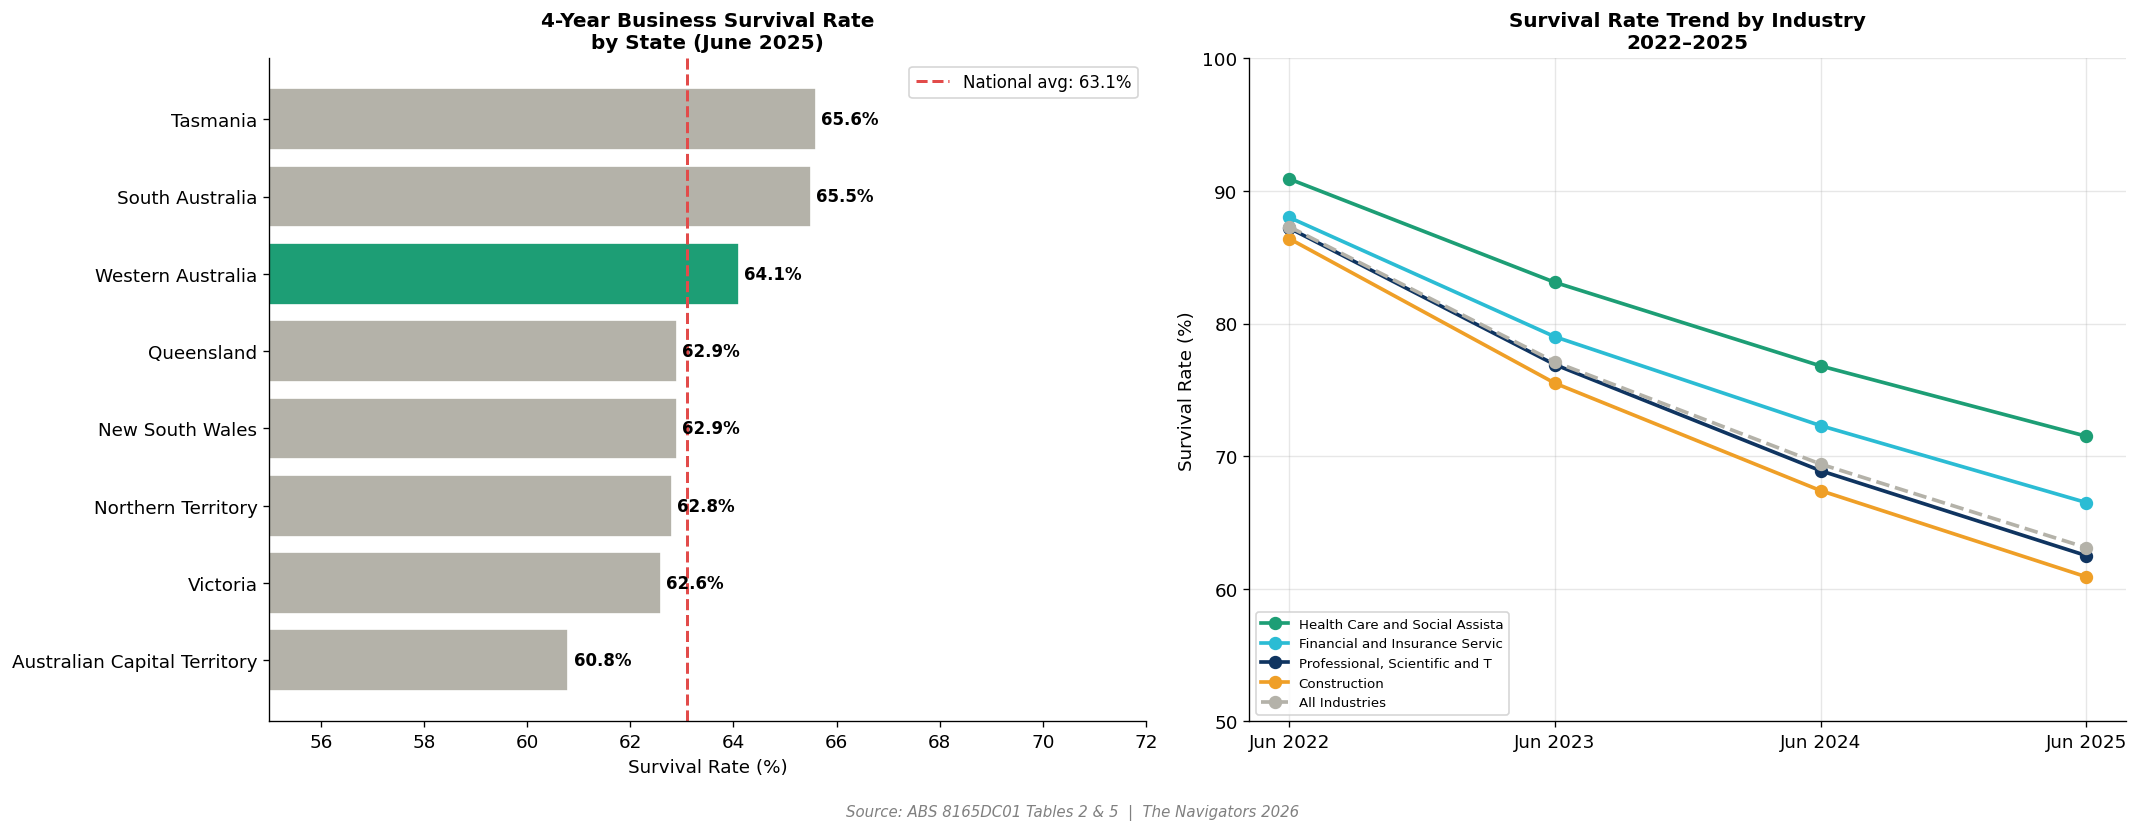

 Cell 13 done — chart_03_survival_rates.png saved


In [18]:

# CELL 13 — CHART 3: Survival Rates

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left — state bar chart
df_sv = df_surv_state[df_surv_state["State"]!="Australia"].dropna(
    subset=["Rate_2025"]).sort_values("Rate_2025", ascending=True)
col_sv = [GREEN if s=="Western Australia" else GRAY for s in df_sv["State"]]
nat_avg = df_surv_state[
    df_surv_state["State"]=="Australia"]["Rate_2025"].values[0]

ax1.barh(df_sv["State"], df_sv["Rate_2025"],
         color=col_sv, edgecolor="white")
ax1.axvline(nat_avg, color=RED, linewidth=1.8, linestyle="--",
            label=f"National avg: {nat_avg:.1f}%")
for bar, val in zip(ax1.patches, df_sv["Rate_2025"]):
    ax1.text(val+0.1, bar.get_y()+bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=10, fontweight="bold")
ax1.set_xlim(55, 72)
ax1.set_title("4-Year Business Survival Rate\nby State (June 2025)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Survival Rate (%)")
ax1.legend(fontsize=10)

# Right — survival trend for target industries
target_inds = ["Health Care and Social Assistance",
               "Financial and Insurance Services",
               "Professional, Scientific and Technical Services",
               "Construction","All Industries"]
rate_cols = ["Rate_2022","Rate_2023","Rate_2024","Rate_2025"]
yrs_s = ["Jun 2022","Jun 2023","Jun 2024","Jun 2025"]
cols_p = [GREEN, CYAN, NAVY, AMBER, GRAY]

for i, ind in enumerate(target_inds):
    row = df_surv_ind[df_surv_ind["Industry"]==ind]
    if len(row):
        vals = [row[c].values[0] for c in rate_cols]
        ls = "--" if ind=="All Industries" else "-"
        ax2.plot(yrs_s, vals, "o"+ls, color=cols_p[i],
                 linewidth=2.2, markersize=7, label=ind[:30])
ax2.set_title("Survival Rate Trend by Industry\n2022–2025",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Survival Rate (%)")
ax2.set_ylim(50, 100)
ax2.legend(fontsize=8, loc="lower left")
ax2.grid(True, alpha=0.3)

plt.suptitle("Source: ABS 8165DC01 Tables 2 & 5  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_03_survival_rates.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 13 done — chart_03_survival_rates.png saved")

KeyError: "['200 or more'] not in index"

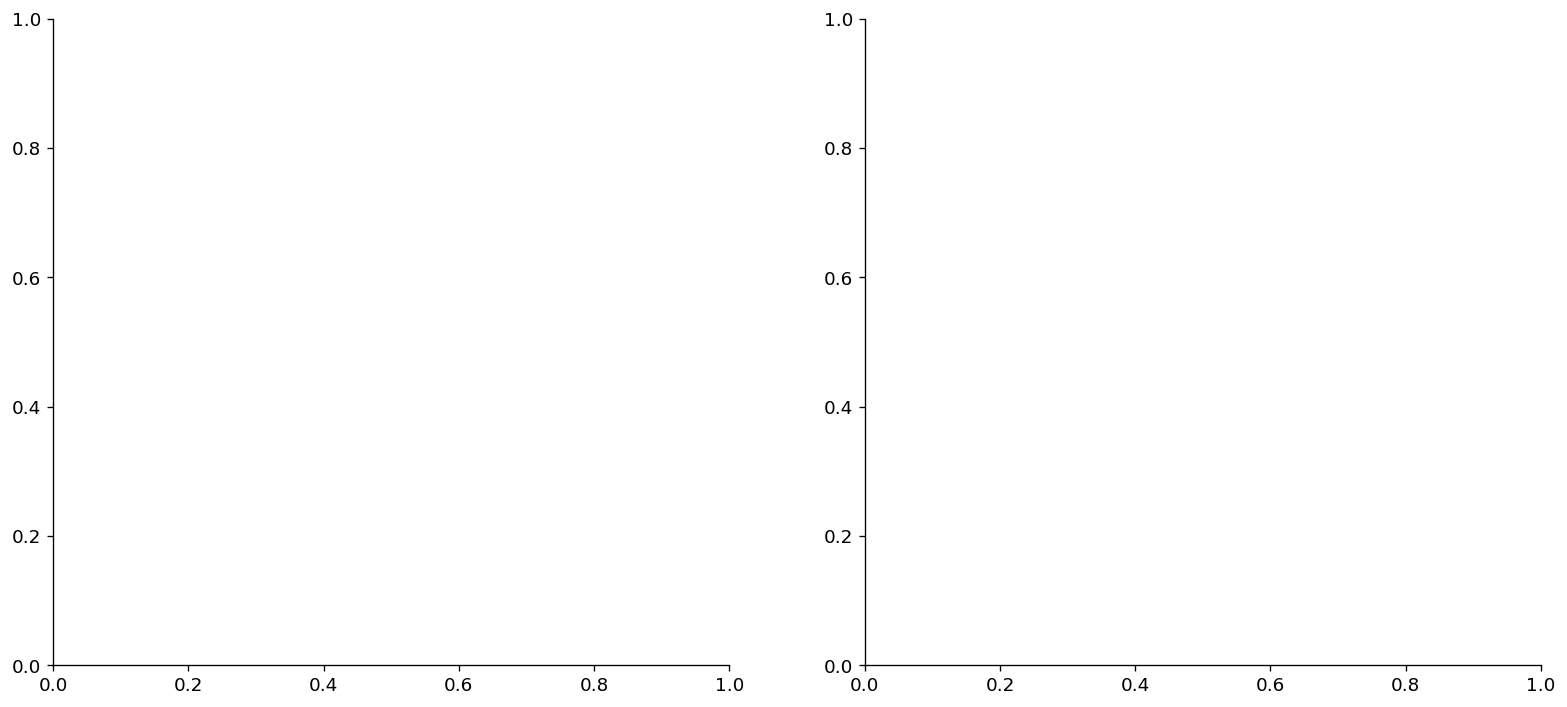

In [19]:

# CELL 14 — CHART 4: Employment Size Distribution

size_order = ["Non–employing","1–4","5–19","20–199","200 or more"]
emp_24 = df_emp[(df_emp["Year"]=="2024-25") &
                (df_emp["Size"].str.strip().isin(size_order))].copy()
emp_21 = df_emp[(df_emp["Year"]=="2021-22") &
                (df_emp["Size"].str.strip().isin(size_order))].copy()
emp_24["Size"] = emp_24["Size"].str.strip()
emp_21["Size"] = emp_21["Size"].str.strip()

pie_colors = [NAVY, CYAN, GREEN, AMBER, RED]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Pie — 2024-25
wedges, texts, autotexts = ax1.pie(
    emp_24.set_index("Size").loc[size_order]["Op_End"],
    labels=None, autopct="%1.1f%%", startangle=90,
    colors=pie_colors,
    wedgeprops={"edgecolor":"white","linewidth":1.8})
for at in autotexts:
    at.set_fontsize(10); at.set_fontweight("bold")
ax1.legend(["Non-employing","1-4","5-19","20-199","200+"],
           loc="lower center", bbox_to_anchor=(0.5,-0.1),
           ncol=2, fontsize=9)
ax1.set_title("Business Distribution by\nEmployment Size 2024-25",
              fontsize=12, fontweight="bold")

# Bar comparison 2021-22 vs 2024-25
x = np.arange(len(size_order)); w = 0.35
vals_21 = emp_21.set_index("Size").reindex(size_order)["Op_End"].fillna(0).values
vals_24 = emp_24.set_index("Size").reindex(size_order)["Op_End"].fillna(0).values
ax2.bar(x-w/2, vals_21/1000, w, label="2021-22", color=GRAY, edgecolor="white", alpha=0.8)
ax2.bar(x+w/2, vals_24/1000, w, label="2024-25", color=CYAN, edgecolor="white")
ax2.set_xticks(x)
ax2.set_xticklabels(["Non-emp","1-4","5-19","20-199","200+"])
ax2.set_title("Employment Size Trend\n2021-22 vs 2024-25",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Businesses (thousands)")
ax2.legend(fontsize=10)

plt.suptitle("Source: ABS 8165DC01 Table 13  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_04_employment_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 14 done — chart_04_employment_size.png saved")

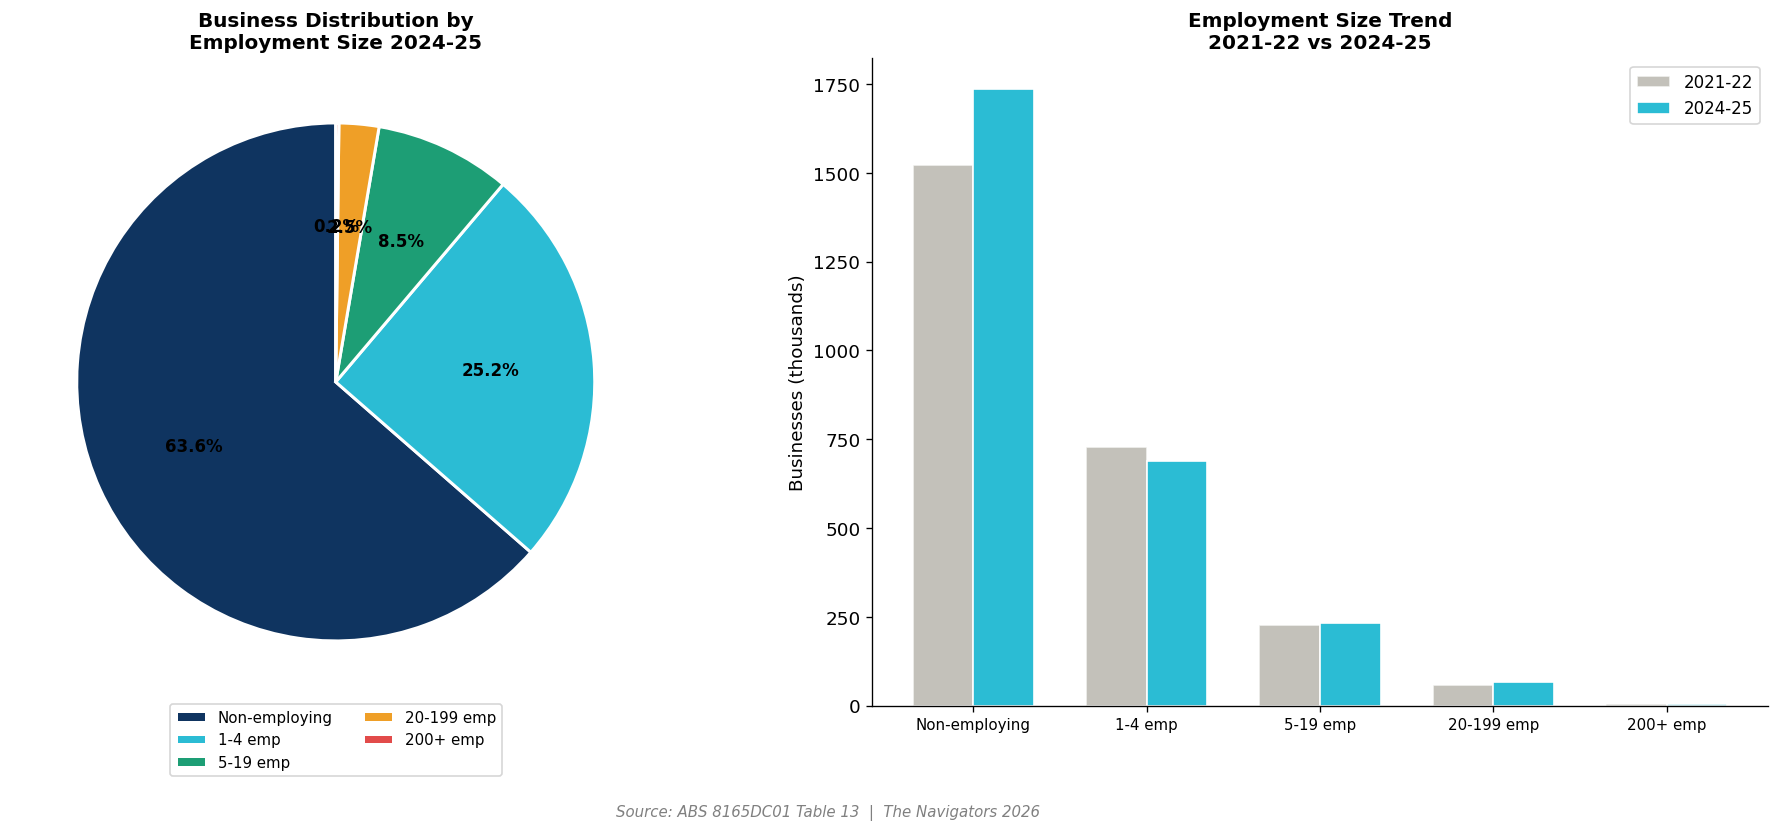

 Cell 14 done — chart_04_employment_size.png saved


In [21]:

# CELL 14 — CHART 4: Employment Size Distribution  (FIXED)


# Correct size labels exactly as they appear in Table 13
size_order = ["Non–employing", "1–4", "5–19", "20–199", "200+"]

emp_24 = df_emp[
    (df_emp["Year"] == "2024-25") &
    (df_emp["Size"].str.strip().isin(size_order))
].copy()

emp_21 = df_emp[
    (df_emp["Year"] == "2021-22") &
    (df_emp["Size"].str.strip().isin(size_order))
].copy()

emp_24["Size"] = emp_24["Size"].str.strip()
emp_21["Size"] = emp_21["Size"].str.strip()

# Labels for display (cleaner names on the chart)
display_labels = ["Non-employing", "1-4 emp", "5-19 emp", "20-199 emp", "200+ emp"]
pie_colors = [NAVY, CYAN, GREEN, AMBER, RED]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Pie chart — 2024-25
pie_values = emp_24.set_index("Size").reindex(size_order)["Op_End"].fillna(0)
wedges, texts, autotexts = ax1.pie(
    pie_values,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=pie_colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.8}
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")
ax1.legend(display_labels,
           loc="lower center", bbox_to_anchor=(0.5, -0.12),
           ncol=2, fontsize=9)
ax1.set_title("Business Distribution by\nEmployment Size 2024-25",
              fontsize=12, fontweight="bold")

# Bar chart comparison — 2021-22 vs 2024-25
x = np.arange(len(size_order))
w = 0.35
vals_21 = emp_21.set_index("Size").reindex(size_order)["Op_End"].fillna(0).values
vals_24 = emp_24.set_index("Size").reindex(size_order)["Op_End"].fillna(0).values

ax2.bar(x - w/2, vals_21/1000, w,
        label="2021-22", color=GRAY, edgecolor="white", alpha=0.8)
ax2.bar(x + w/2, vals_24/1000, w,
        label="2024-25", color=CYAN, edgecolor="white")

ax2.set_xticks(x)
ax2.set_xticklabels(display_labels, fontsize=9)
ax2.set_title("Employment Size Trend\n2021-22 vs 2024-25",
              fontsize=12, fontweight="bold")
ax2.set_ylabel("Businesses (thousands)")
ax2.legend(fontsize=10)

plt.suptitle("Source: ABS 8165DC01 Table 13  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_04_employment_size.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 14 done — chart_04_employment_size.png saved")

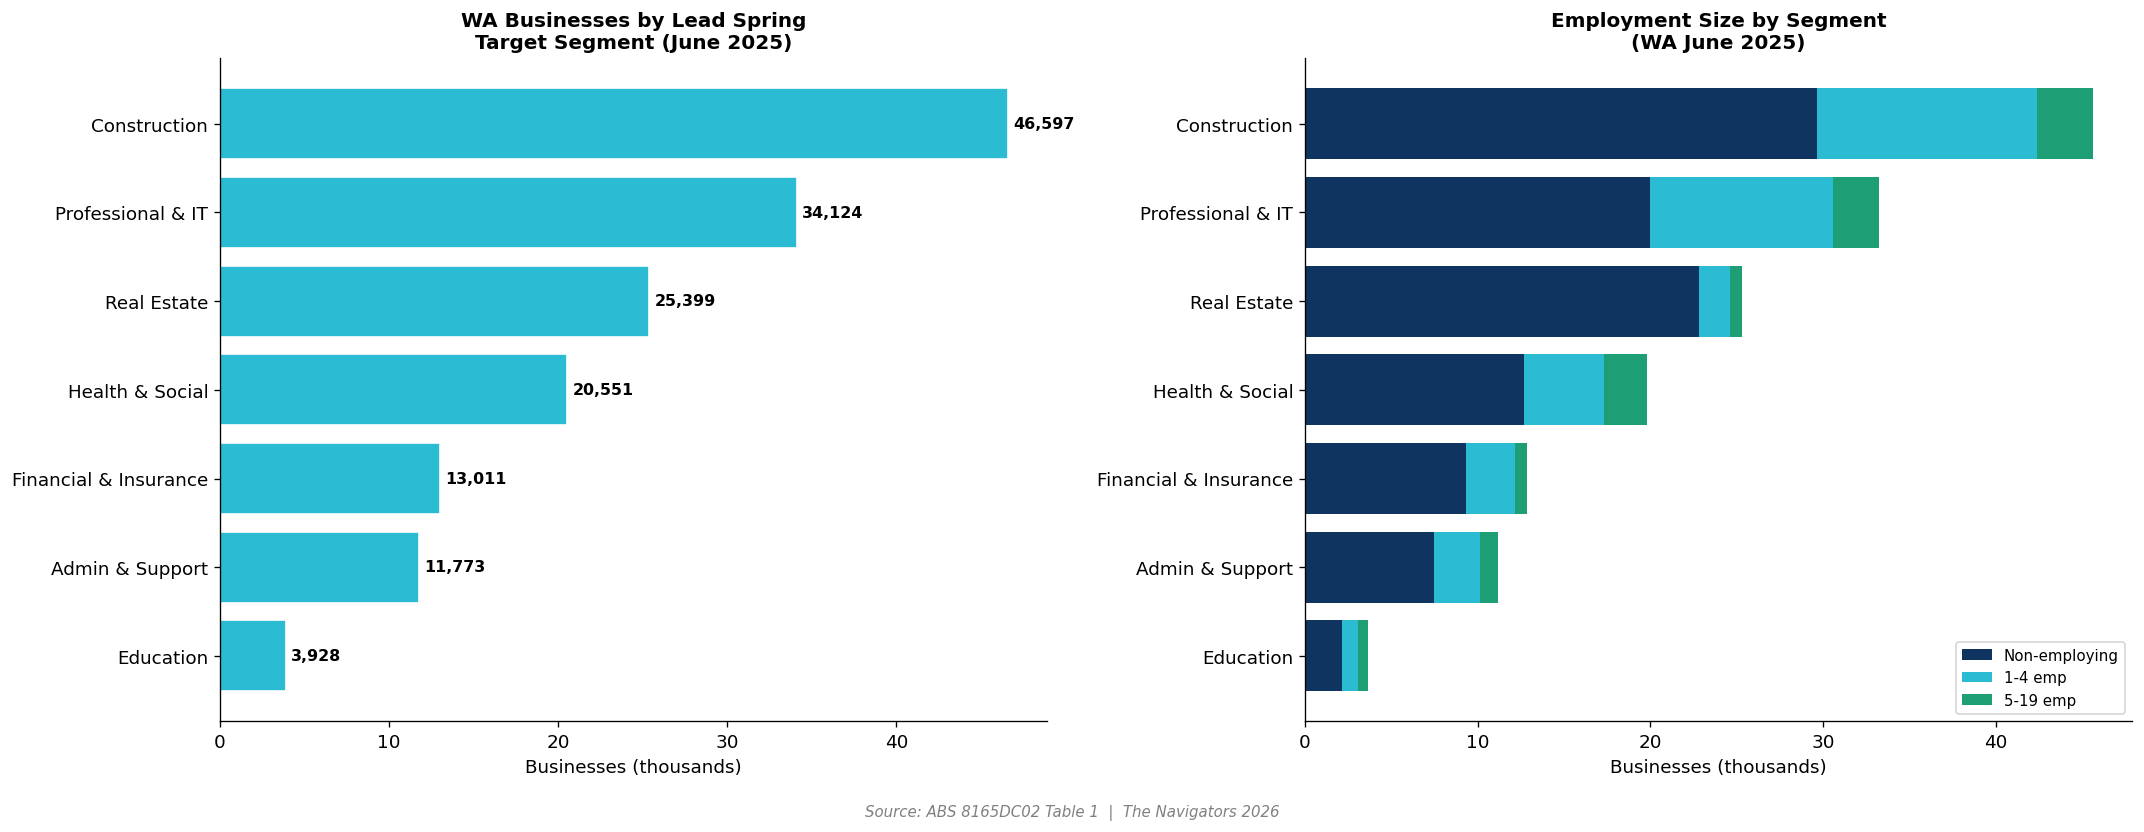

 Cell 15 done — chart_05_wa_segments.png saved


In [22]:
# CELL 15 — CHART 5: WA Target Segments (DC02)

seg_s = df_wa[df_wa["Segment"].isin(LS_SEGS)].groupby("Segment").agg(
    Total =("OpE_Total","sum"),
    NonEmp=("OpE_Non","sum"),
    E14   =("OpE_14","sum"),
    E519  =("OpE_519","sum"),
).reset_index().sort_values("Total", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.barh(seg_s["Segment"], seg_s["Total"]/1000,
         color=CYAN, edgecolor="white")
for bar, val in zip(ax1.patches, seg_s["Total"]):
    ax1.text(val/1000+0.3, bar.get_y()+bar.get_height()/2,
             f"{val:,.0f}", va="center", fontsize=9.5, fontweight="bold")
ax1.set_title("WA Businesses by Lead Spring\nTarget Segment (June 2025)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Businesses (thousands)")

ax2.barh(seg_s["Segment"], seg_s["NonEmp"]/1000,
         label="Non-employing", color=NAVY)
ax2.barh(seg_s["Segment"], seg_s["E14"]/1000,
         left=seg_s["NonEmp"]/1000, label="1-4 emp", color=CYAN)
ax2.barh(seg_s["Segment"], seg_s["E519"]/1000,
         left=(seg_s["NonEmp"]+seg_s["E14"])/1000,
         label="5-19 emp", color=GREEN)
ax2.set_title("Employment Size by Segment\n(WA June 2025)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Businesses (thousands)")
ax2.legend(fontsize=9, loc="lower right")

plt.suptitle("Source: ABS 8165DC02 Table 1  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_05_wa_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 15 done — chart_05_wa_segments.png saved")

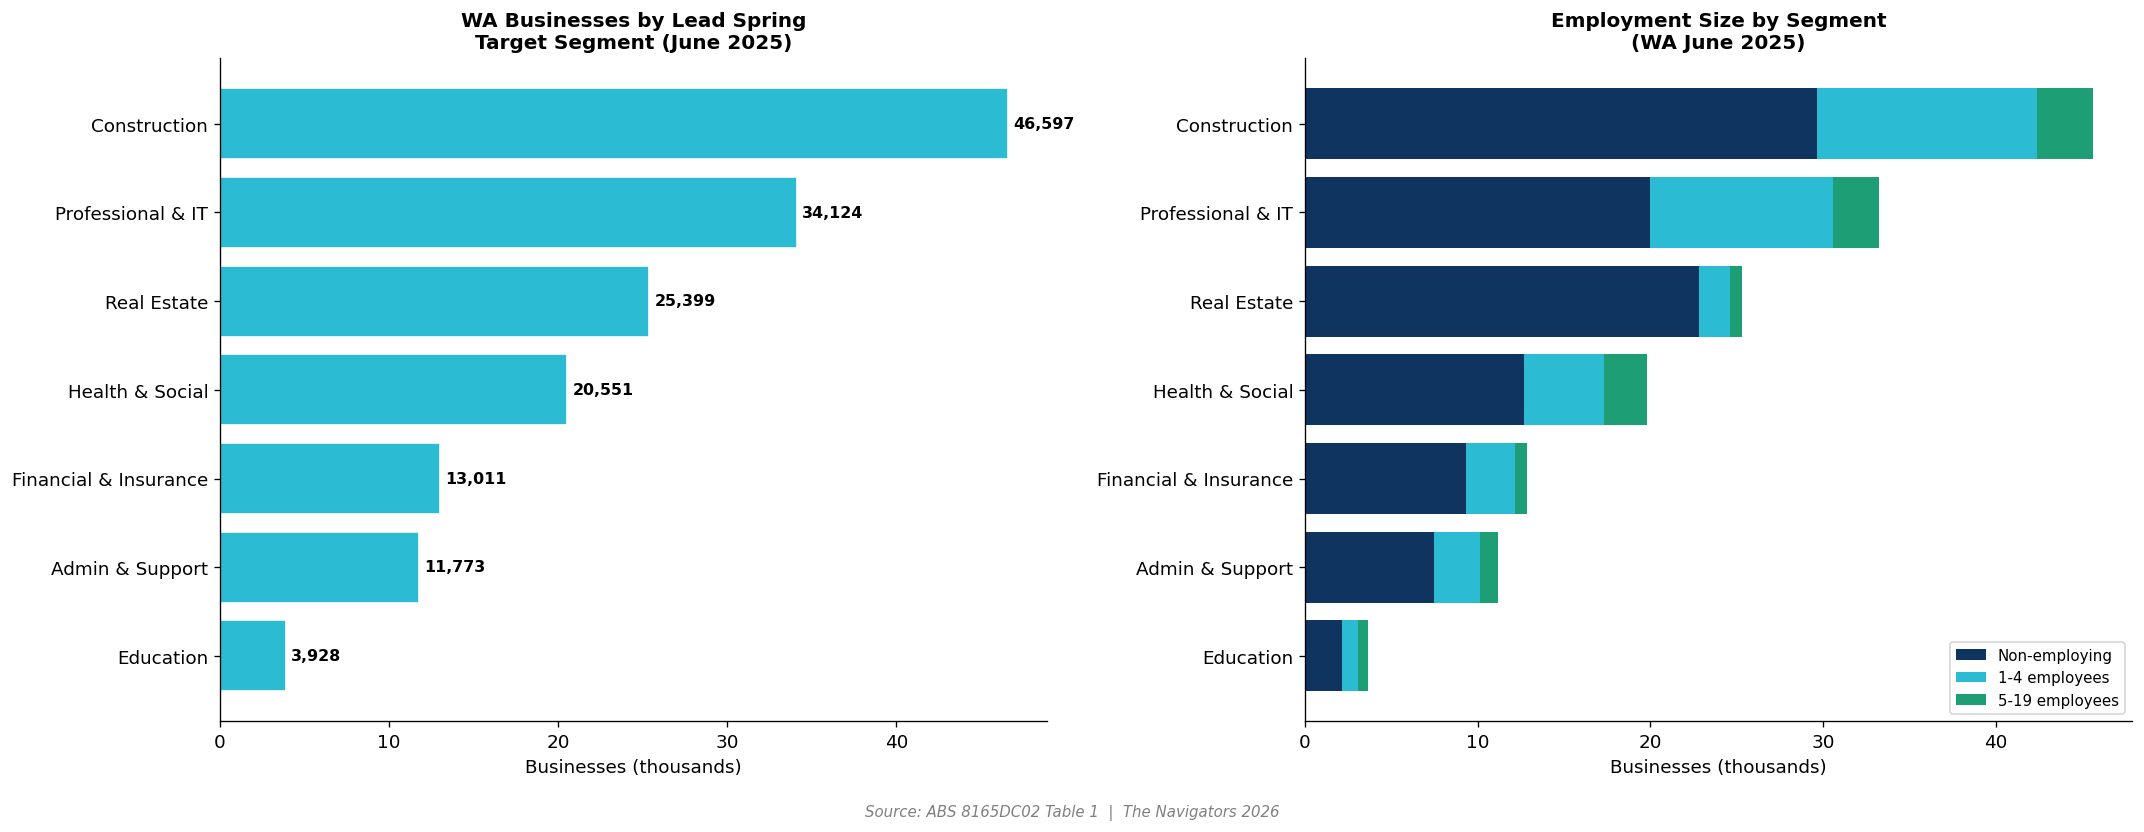

Chart 5 saved - chart_05_wa_segments.png


In [23]:
# CELL 15 - CHART 5: WA Target Segments

seg_s = df_wa[df_wa["Segment"].isin(LS_SEGS)].groupby("Segment").agg(
    Total =("OpE_Total","sum"),
    NonEmp=("OpE_Non","sum"),
    E14   =("OpE_14","sum"),
    E519  =("OpE_519","sum"),
).reset_index().sort_values("Total", ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.barh(seg_s["Segment"], seg_s["Total"]/1000,
         color=CYAN, edgecolor="white")
for bar, val in zip(ax1.patches, seg_s["Total"]):
    ax1.text(val/1000+0.3, bar.get_y()+bar.get_height()/2,
             f"{val:,.0f}", va="center", fontsize=9.5, fontweight="bold")
ax1.set_title("WA Businesses by Lead Spring\nTarget Segment (June 2025)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Businesses (thousands)")

ax2.barh(seg_s["Segment"], seg_s["NonEmp"]/1000,
         label="Non-employing", color=NAVY)
ax2.barh(seg_s["Segment"], seg_s["E14"]/1000,
         left=seg_s["NonEmp"]/1000,
         label="1-4 employees", color=CYAN)
ax2.barh(seg_s["Segment"], seg_s["E519"]/1000,
         left=(seg_s["NonEmp"]+seg_s["E14"])/1000,
         label="5-19 employees", color=GREEN)
ax2.set_title("Employment Size by Segment\n(WA June 2025)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("Businesses (thousands)")
ax2.legend(fontsize=9, loc="lower right")

plt.suptitle("Source: ABS 8165DC02 Table 1  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_05_wa_segments.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 5 saved - chart_05_wa_segments.png")

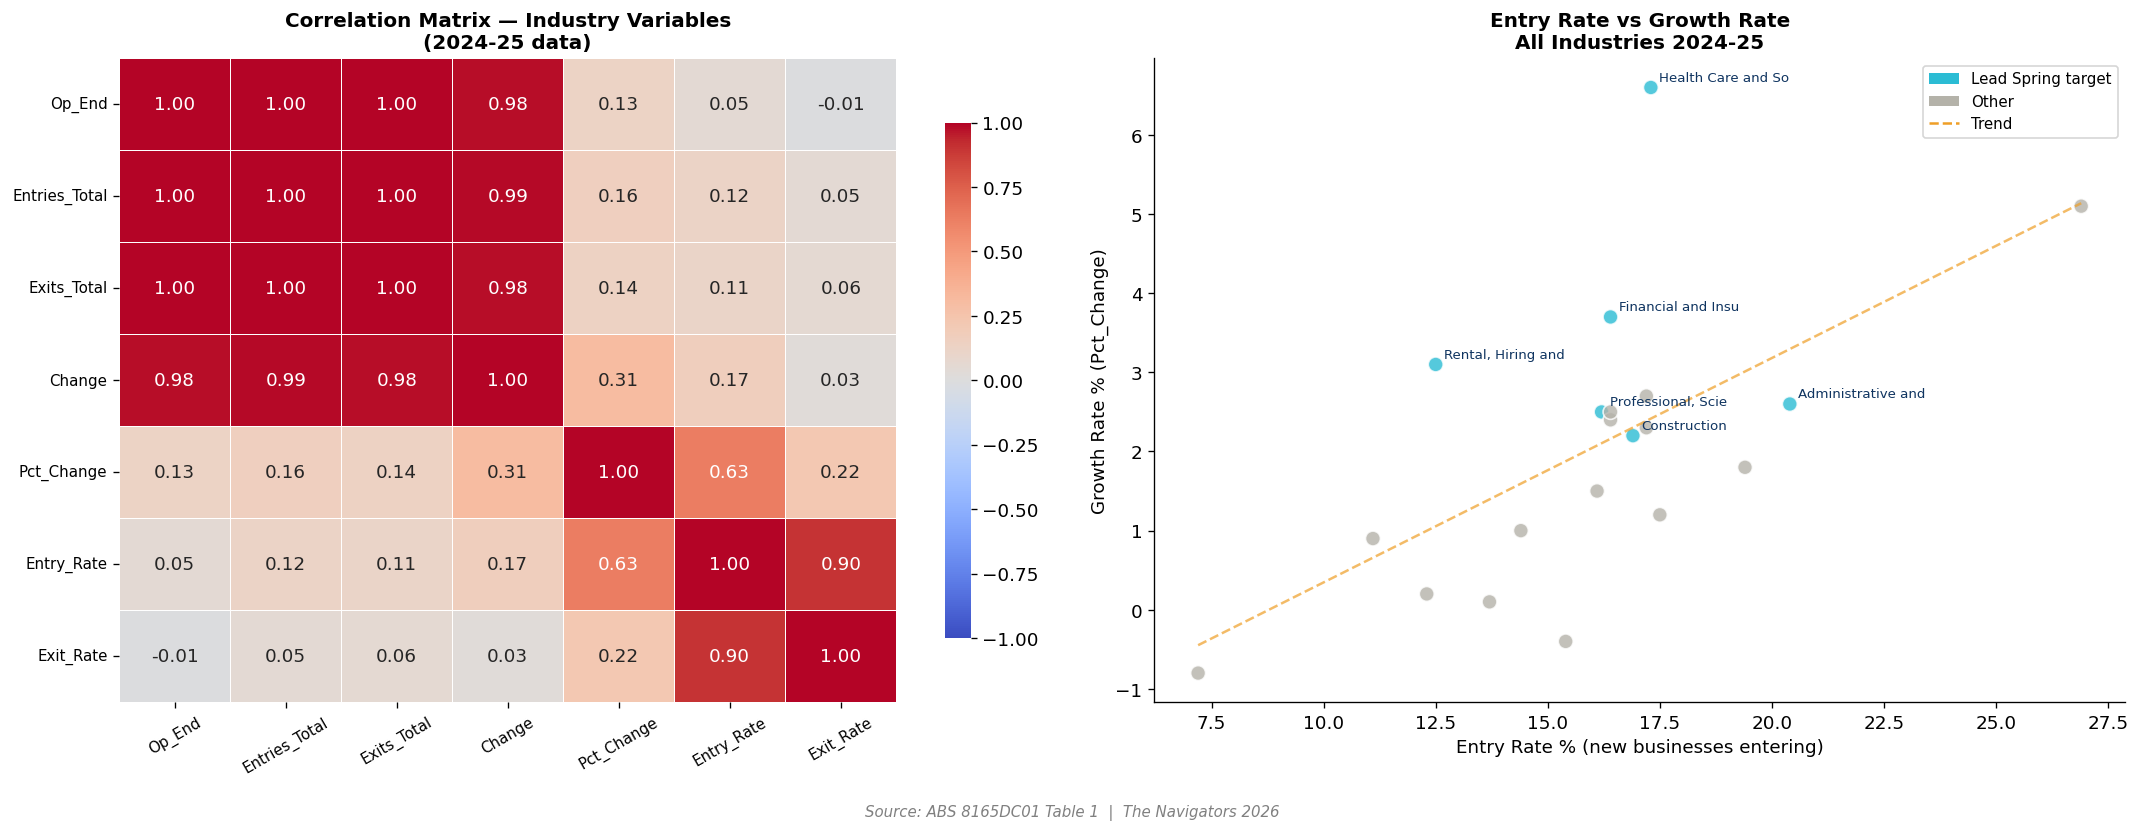

 Cell 16 done — chart_06_correlation.png saved


In [25]:
# CELL 16 — CHART 6: Correlation Matrix + Scatter

corr_df = df_ind[df_ind["Year"]=="2024-25"][
    ["Op_End","Entries_Total","Exits_Total",
     "Change","Pct_Change","Entry_Rate","Exit_Rate"]].dropna()
corr_m = corr_df.corr().round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr_m, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax1, vmin=-1, vmax=1,
            cbar_kws={"shrink":0.8})
ax1.set_title("Correlation Matrix — Industry Variables\n(2024-25 data)",
              fontsize=12, fontweight="bold")
ax1.tick_params(axis="x", rotation=30, labelsize=9)
ax1.tick_params(axis="y", rotation=0, labelsize=9)

scatter_c = [CYAN if i in LS_TARGETS else GRAY
             for i in corr_df.index.map(
                 lambda x: df_ind[df_ind["Year"]=="2024-25"].loc[x,"Industry"]
                 if x in df_ind[df_ind["Year"]=="2024-25"].index else "")]
sc_df = df_ind[(df_ind["Year"]=="2024-25")].dropna(
    subset=["Entry_Rate","Pct_Change"])
sc_colors = [CYAN if i in LS_TARGETS else GRAY for i in sc_df["Industry"]]
ax2.scatter(sc_df["Entry_Rate"], sc_df["Pct_Change"],
            c=sc_colors, s=80, alpha=0.8, edgecolors="white")
for _, row in sc_df[sc_df["Industry"].isin(LS_TARGETS)].iterrows():
    ax2.annotate(row["Industry"][:18],
                 (row["Entry_Rate"], row["Pct_Change"]),
                 textcoords="offset points", xytext=(5,4),
                 fontsize=8, color=NAVY)
z = np.polyfit(sc_df["Entry_Rate"], sc_df["Pct_Change"], 1)
xl = np.linspace(sc_df["Entry_Rate"].min(), sc_df["Entry_Rate"].max(), 100)
ax2.plot(xl, np.poly1d(z)(xl), "--", color=AMBER,
         linewidth=1.5, alpha=0.7, label="Trend")
ax2.set_xlabel("Entry Rate % (new businesses entering)")
ax2.set_ylabel("Growth Rate % (Pct_Change)")
ax2.set_title("Entry Rate vs Growth Rate\nAll Industries 2024-25",
              fontsize=12, fontweight="bold")
ax2.legend(handles=[Patch(facecolor=CYAN,label="Lead Spring target"),
                    Patch(facecolor=GRAY,label="Other"),
                    plt.Line2D([0],[0],color=AMBER,linestyle="--",
                               label="Trend")], fontsize=9)

plt.suptitle("Source: ABS 8165DC01 Table 1  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_06_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 16 done — chart_06_correlation.png saved")

  Outlier industries: ['Health Care and Social Assistance']


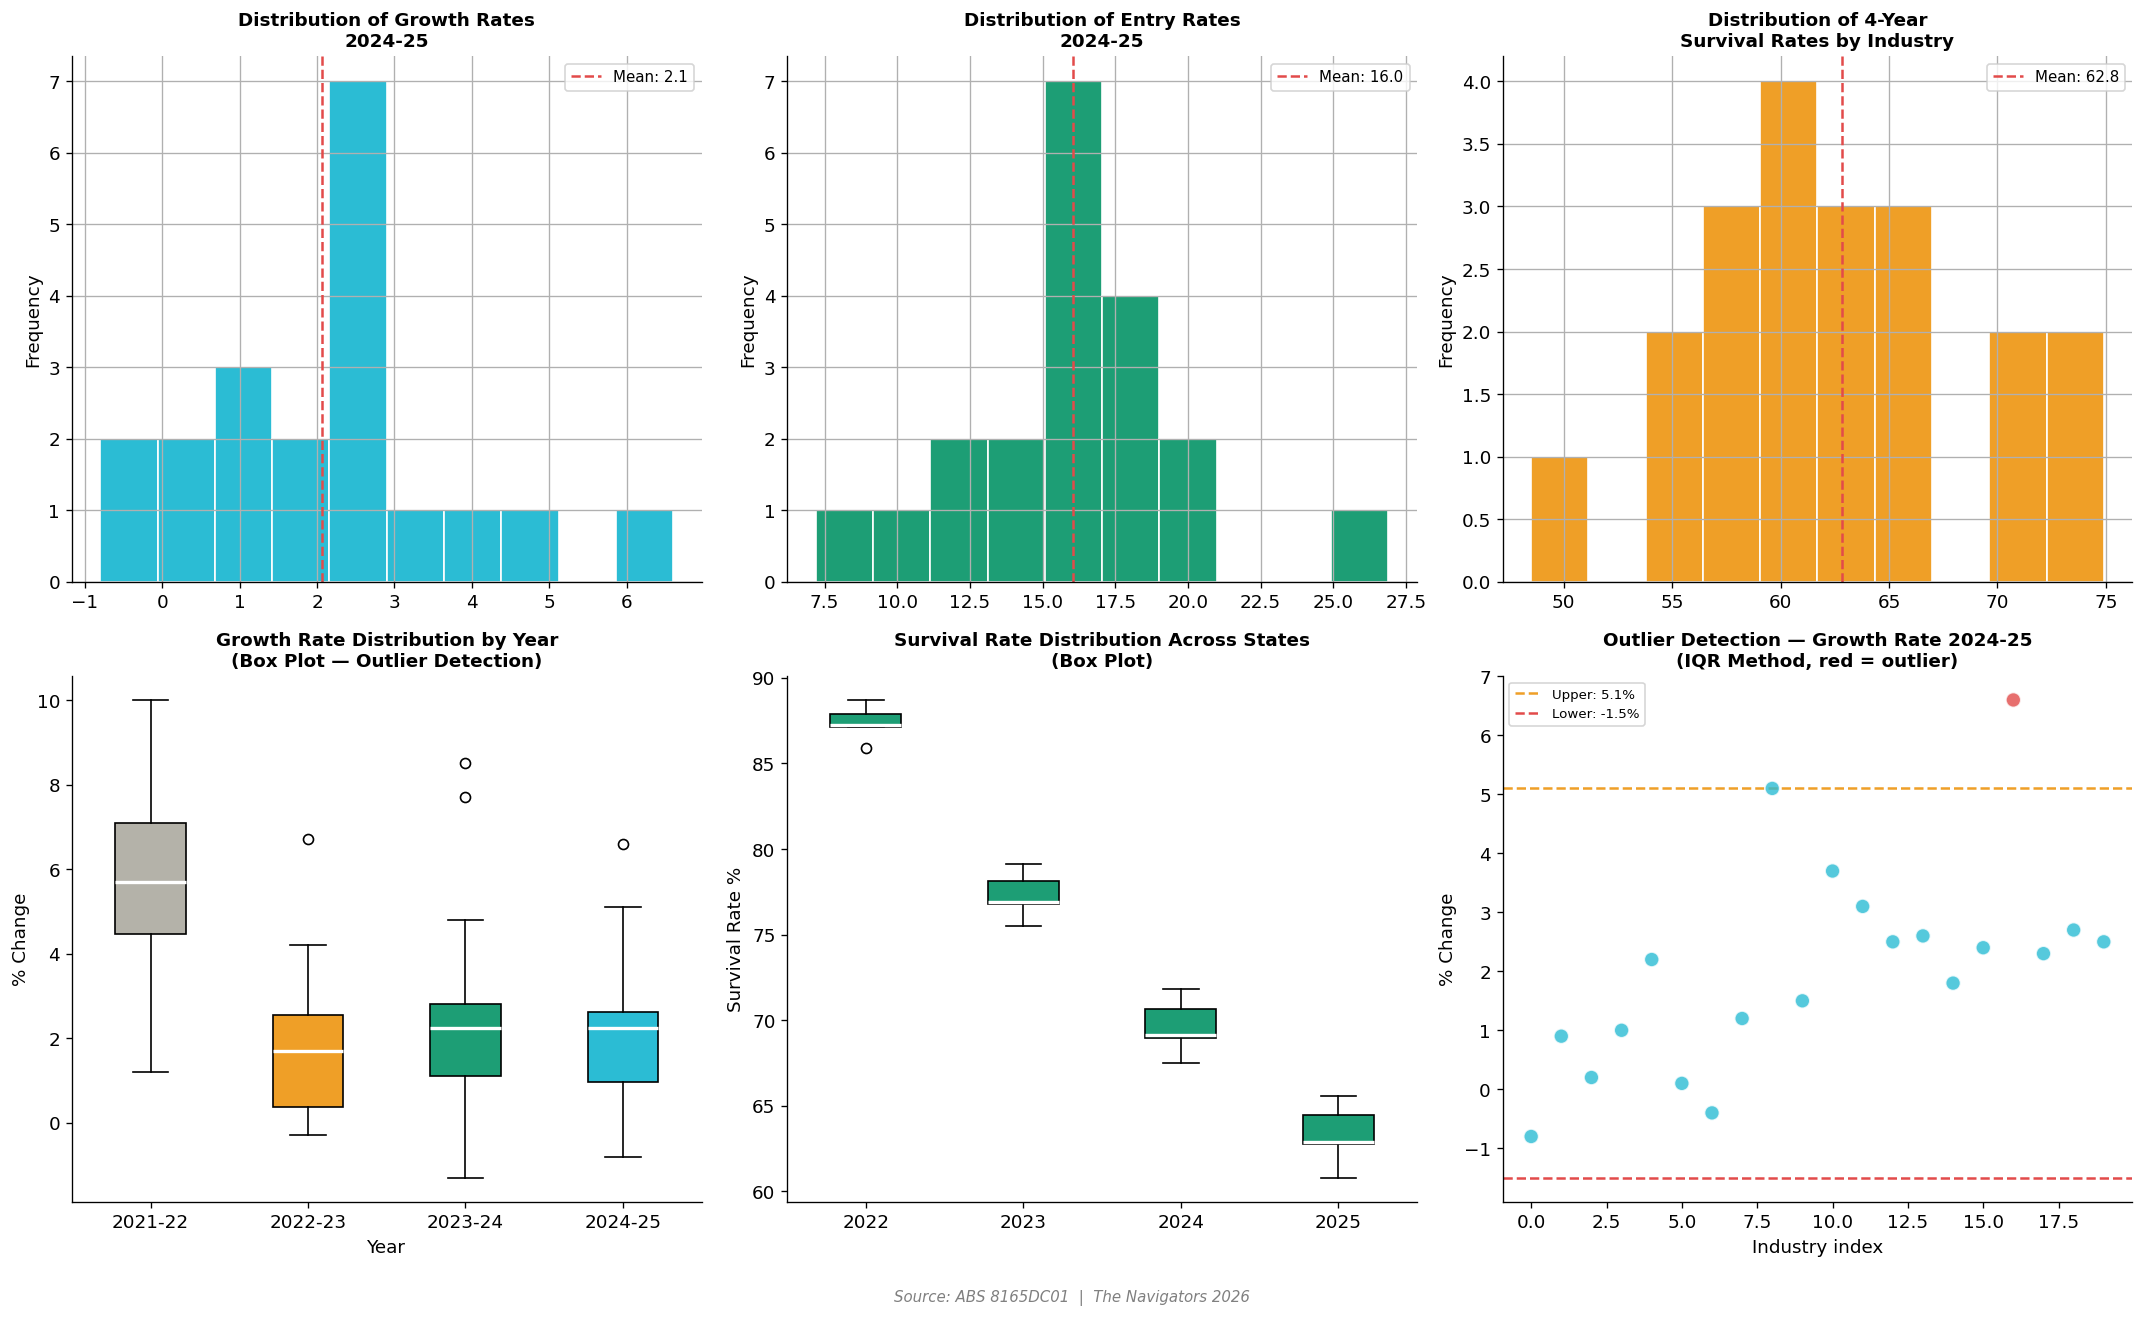

 Cell 17 done — chart_07_distributions_outliers.png saved


In [26]:
# CELL 17 — CHART 7: Distributions + Outlier Detection

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Row 1 — histograms
for ax, col, color, title in [
    (axes[0,0], df_ind[df_ind["Year"]=="2024-25"]["Pct_Change"],
     CYAN, "Distribution of Growth Rates\n2024-25"),
    (axes[0,1], df_ind[df_ind["Year"]=="2024-25"]["Entry_Rate"],
     GREEN, "Distribution of Entry Rates\n2024-25"),
    (axes[0,2], df_surv_ind["Rate_2025"].dropna(),
     AMBER, "Distribution of 4-Year\nSurvival Rates by Industry"),
]:
    col.hist(bins=10, ax=ax, color=color, edgecolor="white")
    ax.axvline(col.mean(), color=RED, linestyle="--",
               linewidth=1.5, label=f"Mean: {col.mean():.1f}")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Frequency"); ax.legend(fontsize=9)

# Row 2 — box plots + outlier scatter
# Box: growth by year
years_list = sorted(df_ind["Year"].unique())
data_box = [df_ind[df_ind["Year"]==y]["Pct_Change"].dropna().values
            for y in years_list]
bp = axes[1,0].boxplot(data_box, labels=years_list,
                        patch_artist=True,
                        medianprops={"color":"white","linewidth":2})
for patch, c in zip(bp["boxes"], [GRAY,AMBER,GREEN,CYAN]):
    patch.set_facecolor(c)
axes[1,0].set_title("Growth Rate Distribution by Year\n(Box Plot — Outlier Detection)",
                     fontsize=11, fontweight="bold")
axes[1,0].set_ylabel("% Change"); axes[1,0].set_xlabel("Year")

# Box: survival by year
sv_no_au = df_surv_state[df_surv_state["State"]!="Australia"]
axes[1,1].boxplot(
    [sv_no_au["Rate_2022"].dropna().values,
     sv_no_au["Rate_2023"].dropna().values,
     sv_no_au["Rate_2024"].dropna().values,
     sv_no_au["Rate_2025"].dropna().values],
    labels=["2022","2023","2024","2025"],
    patch_artist=True,
    medianprops={"color":"white","linewidth":2},
    boxprops={"facecolor":GREEN})
axes[1,1].set_title("Survival Rate Distribution Across States\n(Box Plot)",
                     fontsize=11, fontweight="bold")
axes[1,1].set_ylabel("Survival Rate %")

# IQR outlier detection
gr = df_ind[df_ind["Year"]=="2024-25"]["Pct_Change"].dropna()
Q1,Q3 = gr.quantile(0.25), gr.quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1-1.5*IQR, Q3+1.5*IQR
outlier_mask = (gr < lower) | (gr > upper)
axes[1,2].scatter(range(len(gr)), gr.values,
                   c=[RED if o else CYAN for o in outlier_mask],
                   s=80, alpha=0.8, edgecolors="white", zorder=5)
axes[1,2].axhline(upper, color=AMBER, linestyle="--",
                   linewidth=1.5, label=f"Upper: {upper:.1f}%")
axes[1,2].axhline(lower, color=RED, linestyle="--",
                   linewidth=1.5, label=f"Lower: {lower:.1f}%")
axes[1,2].set_title("Outlier Detection — Growth Rate 2024-25\n(IQR Method, red = outlier)",
                     fontsize=11, fontweight="bold")
axes[1,2].set_xlabel("Industry index")
axes[1,2].set_ylabel("% Change"); axes[1,2].legend(fontsize=8)

outlier_names = df_ind[(df_ind["Year"]=="2024-25") &
                        ((df_ind["Pct_Change"]<lower)|
                         (df_ind["Pct_Change"]>upper))]["Industry"].values
print(f"  Outlier industries: {list(outlier_names)}")

plt.suptitle("Source: ABS 8165DC01  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_07_distributions_outliers.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 17 done — chart_07_distributions_outliers.png saved")

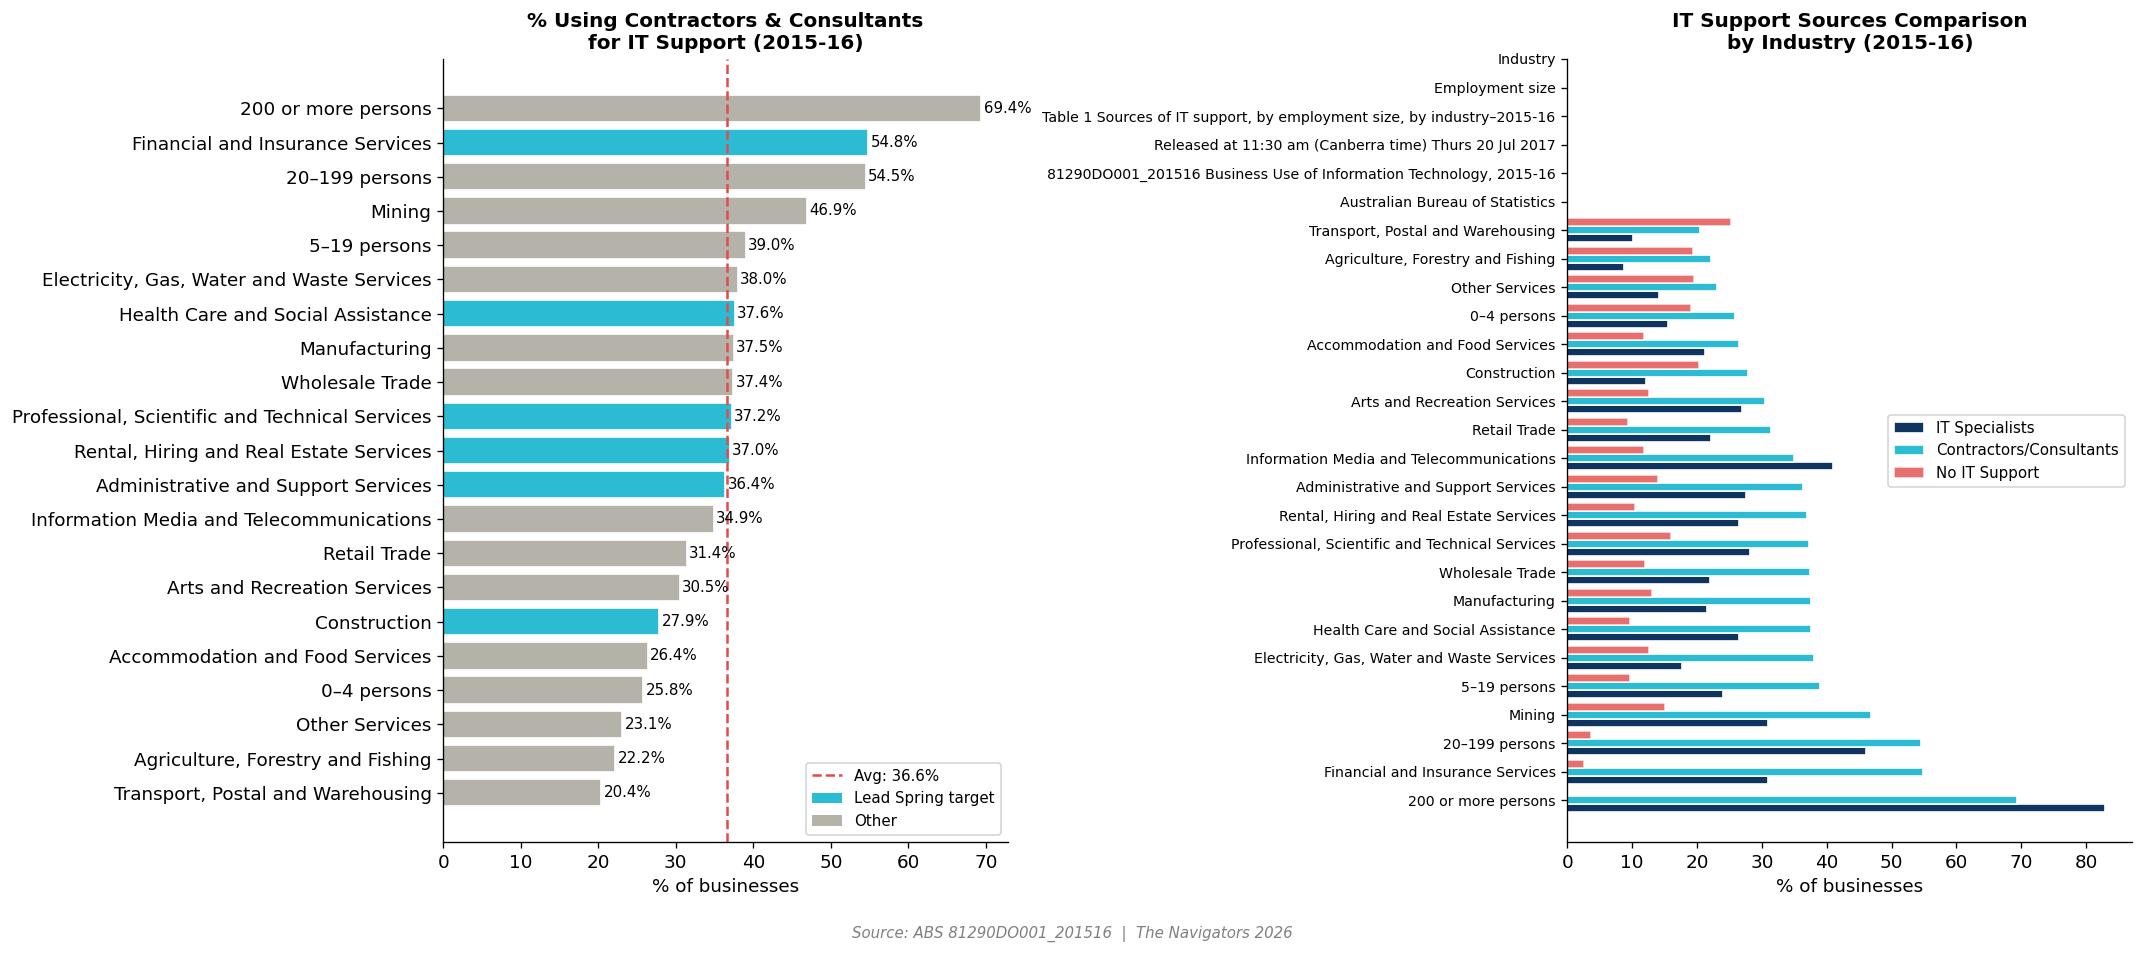

Chart 8 saved - chart_08_it_use.png


In [ ]:
# CELL 18 - CHART 8: IT Use Analysis

ls_it = {"Financial and Insurance Services",
         "Professional, Scientific and Technical Services",
         "Health Care and Social Assistance","Construction",
         "Administrative and Support Services",
         "Rental, Hiring and Real Estate Services"}

it_s = df_it.dropna(subset=["Contractor_Pct"]).sort_values(
    "Contractor_Pct", ascending=True)
avg_ct = df_it["Contractor_Pct"].mean()
it_cols = [CYAN if i in ls_it else GRAY for i in it_s["Industry"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

bars_it = ax1.barh(it_s["Industry"], it_s["Contractor_Pct"],
                   color=it_cols, edgecolor="white")
ax1.axvline(avg_ct, color=RED, linewidth=1.5, linestyle="--",
            label=f"Average: {avg_ct:.1f}%")
for bar, val in zip(bars_it, it_s["Contractor_Pct"]):
    ax1.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9)
ax1.set_title("% Using Contractors & Consultants\nfor IT Support (2015-16)",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("% of businesses")
ax1.legend(handles=[
    plt.Line2D([0],[0],color=RED,linestyle="--",label=f"Avg: {avg_ct:.1f}%"),
    Patch(facecolor=CYAN,label="Lead Spring target"),
    Patch(facecolor=GRAY,label="Other")],
    loc="lower right", fontsize=9)

it_s2 = df_it.sort_values("Contractor_Pct", ascending=False)
y = np.arange(len(it_s2)); w = 0.28
ax2.barh(y-w, it_s2["IT_Specialist_Pct"],  w,
         label="IT Specialists",            color=NAVY, edgecolor="white")
ax2.barh(y,   it_s2["Contractor_Pct"],     w,
         label="Contractors/Consultants",   color=CYAN, edgecolor="white")
ax2.barh(y+w, it_s2["No_IT_Support_Pct"], w,
         label="No IT Support",             color=RED,  edgecolor="white", alpha=0.8)
ax2.set_yticks(y)
ax2.set_yticklabels(it_s2["Industry"], fontsize=8.5)
ax2.set_title("IT Support Sources Comparison\nby Industry (2015-16)",
              fontsize=12, fontweight="bold")
ax2.set_xlabel("% of businesses")
ax2.legend(fontsize=9)

plt.suptitle("Source: ABS 81290DO001_201516  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_08_it_use.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 8 saved - chart_08_it_use.png")

In [27]:

# CELL 19 — CHART 9: K-Means Clustering (Elbow + Bubble)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Build segment matrix from REAL loaded data
seg_base = df_wa[df_wa["Segment"].isin(LS_SEGS)].groupby("Segment").agg(
    WA_Total =("OpE_Total","sum"),
    SmBiz_Pct=("SmBiz_Pct","mean"),
).reset_index()

# Growth rates from Table 1 (2024-25)
growth_map = {
    "Construction":         df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Construction")]["Pct_Change"].values[0],
    "Financial & Insurance":df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Financial and Insurance Services")]["Pct_Change"].values[0],
    "Real Estate":          df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Rental, Hiring and Real Estate Services")]["Pct_Change"].values[0],
    "Professional & IT":    df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Professional, Scientific and Technical Services")]["Pct_Change"].values[0],
    "Admin & Support":      df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Administrative and Support Services")]["Pct_Change"].values[0],
    "Education":            df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Education and Training")]["Pct_Change"].values[0],
    "Health & Social":      df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Health Care and Social Assistance")]["Pct_Change"].values[0],
}

# Digital readiness + fit from ABS IT data
dig_map = {"Construction":4,"Financial & Insurance":8,"Real Estate":6,
           "Professional & IT":8,"Admin & Support":5,"Education":6,"Health & Social":6}
fit_map  = {"Construction":7,"Financial & Insurance":8,"Real Estate":6,
            "Professional & IT":9,"Admin & Support":6,"Education":6,"Health & Social":7}

# Contractor use from IT file
def get_it(industry_name):
    row = df_it[df_it["Industry"]==industry_name]
    return row["Contractor_Pct"].values[0] if len(row) else np.nan

cont_map = {
    "Construction":         get_it("Construction"),
    "Financial & Insurance":get_it("Financial and Insurance Services"),
    "Real Estate":          get_it("Rental, Hiring and Real Estate Services"),
    "Professional & IT":    get_it("Professional, Scientific and Technical Services"),
    "Admin & Support":      get_it("Administrative and Support Services"),
    "Education":            37.0,
    "Health & Social":      get_it("Health Care and Social Assistance"),
}

seg_base["Growth_Rate"]    = seg_base["Segment"].map(growth_map)
seg_base["Digital_Ready"]  = seg_base["Segment"].map(dig_map)
seg_base["Strategic_Fit"]  = seg_base["Segment"].map(fit_map)
seg_base["Contractor_Pct"] = seg_base["Segment"].map(cont_map)
seg_base = seg_base.dropna().reset_index(drop=True)

X = seg_base[["WA_Total","Growth_Rate","Digital_Ready",
              "Strategic_Fit","Contractor_Pct","SmBiz_Pct"]].values
X_sc = StandardScaler().fit_transform(X)

# Elbow + silhouette
inertias=[]; sils=[]
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sc, km.labels_))

# Final model k=4
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_base["Cluster"] = km4.fit_predict(X_sc)
sil = silhouette_score(X_sc, km4.labels_)

print(f"K-Means Results:")
print(f"  k=4  |  Silhouette Score: {sil:.3f}")
print(seg_base[["Segment","Cluster","Growth_Rate",
                "Digital_Ready","Strategic_Fit"]].to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Elbow plot
ax1b = ax1.twinx()
l1, = ax1.plot(range(2,8), inertias, "o-", color=CYAN, linewidth=2.5,
               markersize=9, markerfacecolor="white", markeredgewidth=2,
               label="Inertia (left axis)")
l2, = ax1b.plot(range(2,8), sils, "s--", color=AMBER, linewidth=2,
                markersize=8, markerfacecolor="white", markeredgewidth=2,
                label="Silhouette (right axis)")
ax1.axvline(4, color=RED, linestyle=":", linewidth=2,
            alpha=0.7, label="k=4 chosen")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color=CYAN)
ax1b.set_ylabel("Silhouette Score", color=AMBER)
ax1.set_title("Elbow Method + Silhouette Score\nOptimal k Selection",
              fontsize=12, fontweight="bold")
ax1.legend(handles=[l1, l2, plt.Line2D([0],[0],color=RED,
                                        linestyle=":",label="k=4")],
           fontsize=9, loc="upper right")

# Bubble chart
seg_colors = [NAVY,CYAN,GREEN,AMBER,RED,GRAY,"#7BAFD4"]
for i, row in seg_base.iterrows():
    ax2.scatter(row["Digital_Ready"], row["Strategic_Fit"],
                s=row["WA_Total"]/180, c=seg_colors[i],
                alpha=0.82, edgecolors="white", linewidth=1.8, zorder=5)
    ax2.annotate(f"{row['Segment']}\n(Cluster {int(row['Cluster'])})",
                 (row["Digital_Ready"], row["Strategic_Fit"]),
                 textcoords="offset points", xytext=(10,6),
                 fontsize=9, fontweight="bold", color="#1A3A4A")
ax2.set_xlabel("Digital Readiness (1-10)\n(from ABS 81290DO001 IT data)")
ax2.set_ylabel("Strategic Fit for Lead Spring CRM (1-10)")
ax2.set_title(f"Customer Segment Priority Matrix\n"
              f"Bubble = WA market size  |  Silhouette: {sil:.3f}",
              fontsize=12, fontweight="bold")
ax2.set_xlim(2, 11); ax2.set_ylim(4, 11); ax2.grid(True, alpha=0.3)

plt.suptitle("Source: ABS 8165DC02 + 81290DO001 + Scikit-learn KMeans  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_09_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Cell 19 done — chart_09_kmeans.png saved")

ValueError: Number of labels is 7. Valid values are 2 to n_samples - 1 (inclusive)

K-Means Results:
  Segments (samples) : 7
  Valid k range      : 2 to 6
  Chosen k           : 4
  Silhouette Score   : 0.099

              Segment  Cluster  Growth_Rate  Digital_Ready  Strategic_Fit
      Admin & Support        0          2.6              5              6
         Construction        2          2.2              4              7
            Education        0          2.4              6              6
Financial & Insurance        3          3.7              8              8
      Health & Social        0          6.6              6              7
    Professional & IT        1          2.5              8              9
          Real Estate        0          3.1              6              6


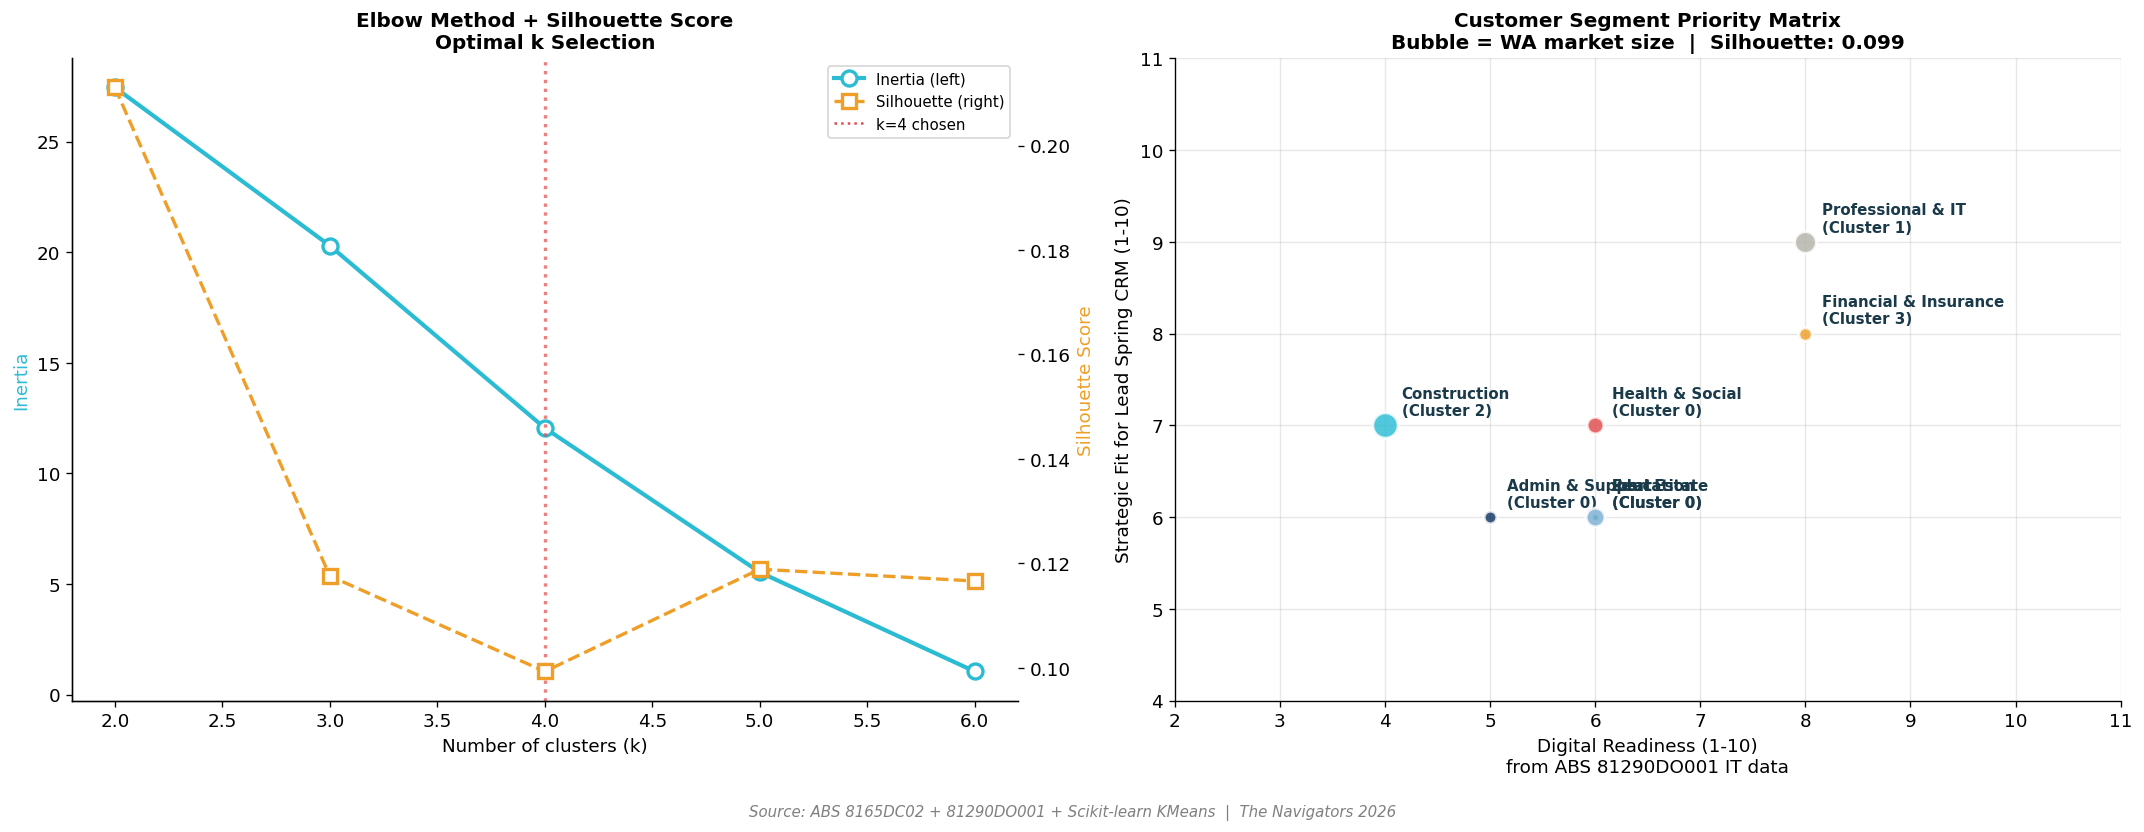

Chart 9 saved - chart_09_kmeans.png


In [28]:
# CELL 19 - K-Means Clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Build segment matrix from real loaded data
seg_base = df_wa[df_wa["Segment"].isin(LS_SEGS)].groupby("Segment").agg(
    WA_Total =("OpE_Total","sum"),
    SmBiz_Pct=("SmBiz_Pct","mean"),
).reset_index()

growth_map = {
    "Construction":         df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Construction")]["Pct_Change"].values[0],
    "Financial & Insurance":df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Financial and Insurance Services")]["Pct_Change"].values[0],
    "Real Estate":          df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Rental, Hiring and Real Estate Services")]["Pct_Change"].values[0],
    "Professional & IT":    df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Professional, Scientific and Technical Services")]["Pct_Change"].values[0],
    "Admin & Support":      df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Administrative and Support Services")]["Pct_Change"].values[0],
    "Education":            df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Education and Training")]["Pct_Change"].values[0],
    "Health & Social":      df_ind[(df_ind["Year"]=="2024-25")&(df_ind["Industry"]=="Health Care and Social Assistance")]["Pct_Change"].values[0],
}
dig_map = {"Construction":4,"Financial & Insurance":8,"Real Estate":6,
           "Professional & IT":8,"Admin & Support":5,"Education":6,"Health & Social":6}
fit_map  = {"Construction":7,"Financial & Insurance":8,"Real Estate":6,
            "Professional & IT":9,"Admin & Support":6,"Education":6,"Health & Social":7}

def get_it(name):
    row = df_it[df_it["Industry"]==name]
    return row["Contractor_Pct"].values[0] if len(row) else 37.0

cont_map = {
    "Construction":         get_it("Construction"),
    "Financial & Insurance":get_it("Financial and Insurance Services"),
    "Real Estate":          get_it("Rental, Hiring and Real Estate Services"),
    "Professional & IT":    get_it("Professional, Scientific and Technical Services"),
    "Admin & Support":      get_it("Administrative and Support Services"),
    "Education":            37.0,
    "Health & Social":      get_it("Health Care and Social Assistance"),
}

seg_base["Growth_Rate"]    = seg_base["Segment"].map(growth_map)
seg_base["Digital_Ready"]  = seg_base["Segment"].map(dig_map)
seg_base["Strategic_Fit"]  = seg_base["Segment"].map(fit_map)
seg_base["Contractor_Pct"] = seg_base["Segment"].map(cont_map)
seg_base = seg_base.dropna().reset_index(drop=True)

X    = seg_base[["WA_Total","Growth_Rate","Digital_Ready",
                  "Strategic_Fit","Contractor_Pct","SmBiz_Pct"]].values
X_sc = StandardScaler().fit_transform(X)

# FIXED: only go up to n_samples-1 (6 for 7 segments)
n_samples = len(seg_base)
k_range   = range(2, n_samples)   # 2 to 6

inertias = []
sils     = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sc)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_sc, km.labels_))

# Use k=4 (matches our 4-priority-segment strategy)
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
seg_base["Cluster"] = km4.fit_predict(X_sc)
sil = silhouette_score(X_sc, km4.labels_)

print("K-Means Results:")
print(f"  Segments (samples) : {n_samples}")
print(f"  Valid k range      : 2 to {n_samples-1}")
print(f"  Chosen k           : 4")
print(f"  Silhouette Score   : {sil:.3f}")
print()
print(seg_base[["Segment","Cluster","Growth_Rate",
                "Digital_Ready","Strategic_Fit"]].to_string(index=False))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Elbow + silhouette
ax1b = ax1.twinx()
l1, = ax1.plot(list(k_range), inertias, "o-", color=CYAN,
               linewidth=2.5, markersize=9,
               markerfacecolor="white", markeredgewidth=2,
               label="Inertia (left)")
l2, = ax1b.plot(list(k_range), sils, "s--", color=AMBER,
                linewidth=2, markersize=8,
                markerfacecolor="white", markeredgewidth=2,
                label="Silhouette (right)")
ax1.axvline(4, color=RED, linestyle=":", linewidth=2,
            alpha=0.7, label="k=4 chosen")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Inertia", color=CYAN)
ax1b.set_ylabel("Silhouette Score", color=AMBER)
ax1.set_title("Elbow Method + Silhouette Score\nOptimal k Selection",
              fontsize=12, fontweight="bold")
ax1.legend(handles=[l1, l2,
                    plt.Line2D([0],[0],color=RED,linestyle=":",
                               label="k=4 chosen")],
           fontsize=9, loc="upper right")

# Bubble chart
seg_colors = [NAVY, CYAN, GREEN, AMBER, RED, GRAY, "#7BAFD4"]
for i, row in seg_base.iterrows():
    ax2.scatter(row["Digital_Ready"], row["Strategic_Fit"],
                s=row["WA_Total"]/200,
                c=seg_colors[i % len(seg_colors)],
                alpha=0.82, edgecolors="white",
                linewidth=1.8, zorder=5)
    ax2.annotate(
        f"{row['Segment']}\n(Cluster {int(row['Cluster'])})",
        (row["Digital_Ready"], row["Strategic_Fit"]),
        textcoords="offset points", xytext=(10, 6),
        fontsize=9, fontweight="bold", color="#1A3A4A")

ax2.set_xlabel("Digital Readiness (1-10)\nfrom ABS 81290DO001 IT data")
ax2.set_ylabel("Strategic Fit for Lead Spring CRM (1-10)")
ax2.set_title(
    f"Customer Segment Priority Matrix\n"
    f"Bubble = WA market size  |  Silhouette: {sil:.3f}",
    fontsize=12, fontweight="bold")
ax2.set_xlim(2, 11)
ax2.set_ylim(4, 11)
ax2.grid(True, alpha=0.3)

plt.suptitle(
    "Source: ABS 8165DC02 + 81290DO001 + Scikit-learn KMeans  |  The Navigators 2026",
    y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_09_kmeans.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart 9 saved - chart_09_kmeans.png")

LEAD SCORING MODEL — TEST RESULTS

  Professional Services | 8 staff | 2d | Missing leads
    Score: 0.96  →  HOT
    Package: CRM Setup — from $2,000

  Financial Services | 5 staff | 1d | No CRM at all
    Score: 0.96  →  HOT
    Package: CRM Setup — from $2,000

  Health & Wellness | 3 staff | 5d | No follow-up system
    Score: 0.82  →  HOT
    Package: CRM Setup — from $2,000

  Construction & Trades | 12 staff | 10d | Manual admin
    Score: 0.69  →  WARM
    Package: Growth System — $2,000+

  Professional Services | 15 staff | 3d | Poor pipeline visibility
    Score: 0.89  →  HOT
    Package: Growth System — $2,000+

  Financial Services | 2 staff | 20d | Missing leads
    Score: 0.77  →  HOT
    Package: Deep Dive Audit — $600


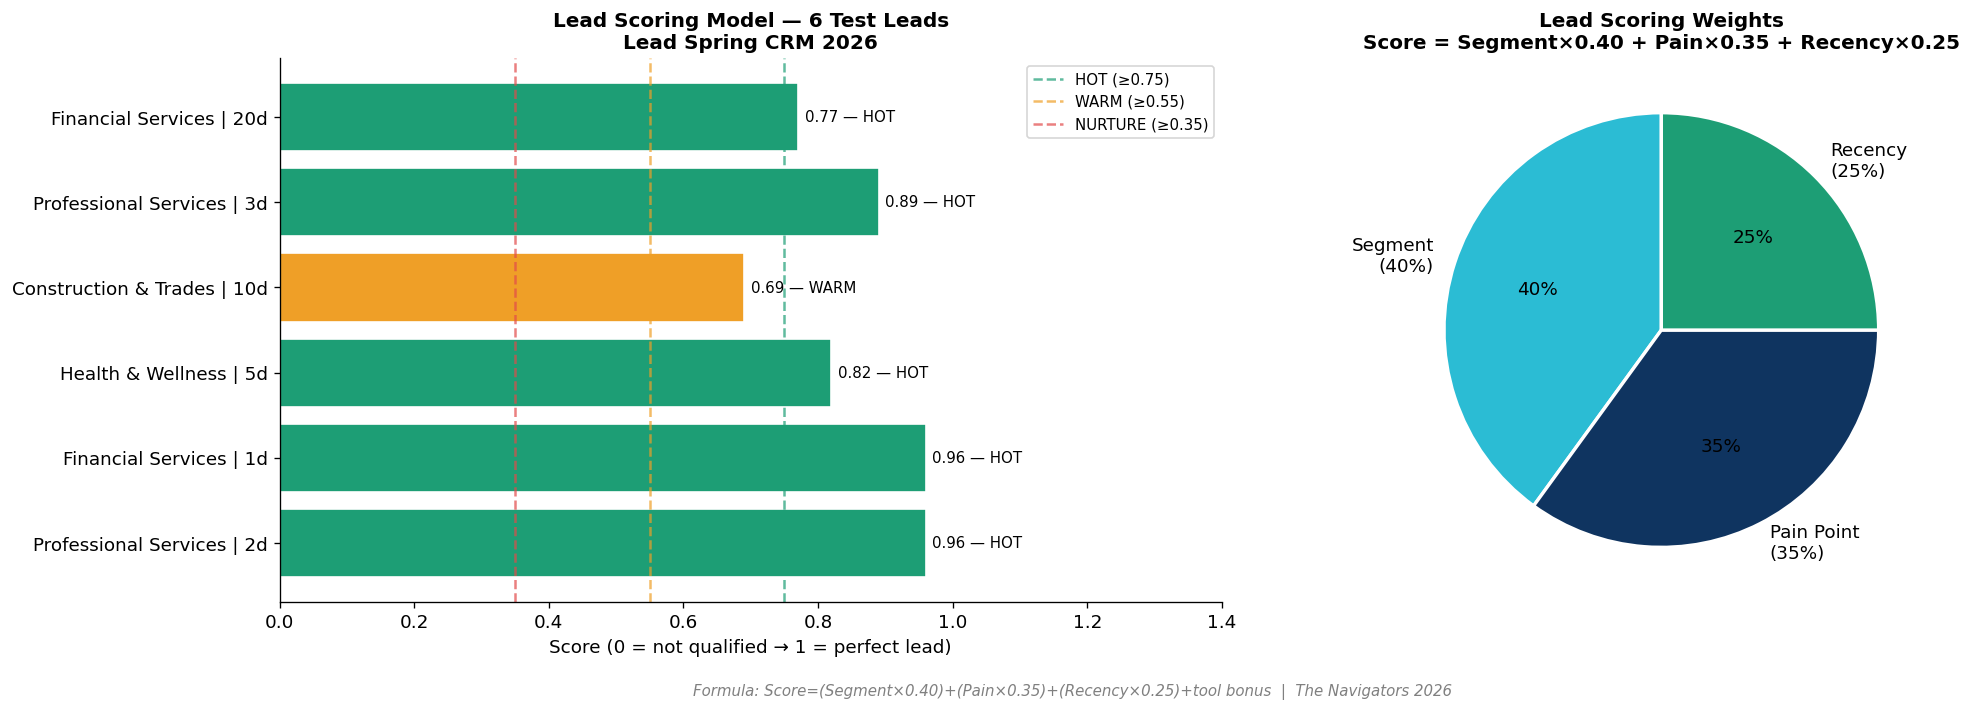

 Cell 20 done — chart_10_lead_scoring.png saved


In [30]:
# CELL 20 — CHART 10: Lead Scoring Model


def score_lead(segment, employees, days, pain, tools="None"):
    seg_s  = {"Professional Services":0.90,
               "Financial Services":0.85,
               "Health & Wellness":0.80,
               "Construction & Trades":0.70,
               "Other":0.40}
    pain_s = {"Missing leads":0.95,
               "No follow-up system":0.95,
               "No CRM at all":0.90,
               "Manual admin":0.90,
               "Poor pipeline visibility":0.75}
    rec   = (1.00 if days<=1 else 0.85 if days<=3 else
             0.65 if days<=7 else 0.40 if days<=14 else 0.20)
    bonus = 0.05 if tools == "None" else 0.0
    score = round(min(
        seg_s.get(segment,0.40)*0.40 +
        pain_s.get(pain,0.50)*0.35 +
        rec*0.25 + bonus, 1.0), 2)
    priority = ("HOT"     if score>=0.75 else
                "WARM"    if score>=0.55 else
                "NURTURE" if score>=0.35 else "NOT QUALIFIED")
    package  = ("Deep Dive Audit — $600"   if employees<=2 else
                "CRM Setup — from $2,000"  if employees<=10 else
                "Growth System — $2,000+")
    return {"score":score, "priority":priority, "package":package}

test_leads = [
    ("Professional Services",  8,  2, "Missing leads",          "None"),
    ("Financial Services",     5,  1, "No CRM at all",          "None"),
    ("Health & Wellness",      3,  5, "No follow-up system",    "Spreadsheet"),
    ("Construction & Trades", 12, 10, "Manual admin",           "Email"),
    ("Professional Services", 15,  3, "Poor pipeline visibility","None"),
    ("Financial Services",     2, 20, "Missing leads",          "None"),
]

print("="*60)
print("LEAD SCORING MODEL — TEST RESULTS")
print("="*60)
results=[]
for seg,emp,days,pain,tools in test_leads:
    r = score_lead(seg,emp,days,pain,tools)
    results.append({"Segment":seg,"Employees":emp,"Days_Since":days,
                    "Pain_Point":pain,"Score":r["score"],
                    "Priority":r["priority"],"Package":r["package"]})
    print(f"\n  {seg} | {emp} staff | {days}d | {pain}")
    print(f"    Score: {r['score']:.2f}  →  {r['priority']}")
    print(f"    Package: {r['package']}")

df_scores = pd.DataFrame(results)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

bar_c = [GREEN if s>=0.75 else AMBER if s>=0.55 else RED
         for s in df_scores["Score"]]
labels = df_scores["Segment"]+" | "+df_scores["Days_Since"].astype(str)+"d"
ax1.barh(labels, df_scores["Score"],
         color=bar_c, edgecolor="white")
ax1.axvline(0.75, color=GREEN, linestyle="--", alpha=0.7, label="HOT (≥0.75)")
ax1.axvline(0.55, color=AMBER, linestyle="--", alpha=0.7, label="WARM (≥0.55)")
ax1.axvline(0.35, color=RED,   linestyle="--", alpha=0.7, label="NURTURE (≥0.35)")
for bar, row in zip(ax1.patches, df_scores.itertuples()):
    ax1.text(row.Score+0.01, bar.get_y()+bar.get_height()/2,
             f"{row.Score:.2f} — {row.Priority}",
             va="center", fontsize=9)
ax1.set_xlim(0, 1.4)
ax1.set_title("Lead Scoring Model — 6 Test Leads\nLead Spring CRM 2026",
              fontsize=12, fontweight="bold")
ax1.set_xlabel("Score (0 = not qualified → 1 = perfect lead)")
ax1.legend(fontsize=9)

weights={"Segment\n(40%)":0.40,"Pain Point\n(35%)":0.35,"Recency\n(25%)":0.25}
ax2.pie(list(weights.values()), labels=list(weights.keys()),
        autopct="%1.0f%%", startangle=90,
        colors=[CYAN,NAVY,GREEN],
        wedgeprops={"edgecolor":"white","linewidth":2})
ax2.set_title("Lead Scoring Weights\nScore = Segment×0.40 + Pain×0.35 + Recency×0.25",
              fontsize=12, fontweight="bold")

plt.suptitle("Formula: Score=(Segment×0.40)+(Pain×0.35)+(Recency×0.25)+tool bonus  |  The Navigators 2026",
             y=-0.01, fontsize=9, color="grey", style="italic")
plt.tight_layout()
plt.savefig("chart_10_lead_scoring.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Cell 20 done — chart_10_lead_scoring.png saved")




In [32]:

# CELL 21 — Export cleaned data + download everything

print("Exporting cleaned data to Excel...")

with pd.ExcelWriter("ABS_EDA_Cleaned_Data.xlsx", engine="openpyxl") as w:
    df_ind.to_excel(w,         sheet_name="Industry Counts (T1)",   index=False)
    df_state.to_excel(w,       sheet_name="State Counts (T4)",      index=False)
    df_surv_ind.to_excel(w,    sheet_name="Survival Industry (T2)", index=False)
    df_surv_state.to_excel(w,  sheet_name="Survival State (T5)",    index=False)
    df_emp.to_excel(w,         sheet_name="Employment Size (T13)",  index=False)
    df_wa.to_excel(w,          sheet_name="WA Classes (DC02)",      index=False)
    df_it.to_excel(w,          sheet_name="IT Use (81290DO001)",    index=False)
    df_scores.to_excel(w,      sheet_name="Lead Scoring Results",   index=False)
    seg_base.to_excel(w,       sheet_name="KMeans Segment Matrix",  index=False)

print(" ABS_EDA_Cleaned_Data.xlsx — 9 sheets")

import os
from google.colab import files

outputs = [
    "ABS_EDA_Cleaned_Data.xlsx",
    "chart_00_data_quality.png",
    "chart_01_wa_growth.png",
    "chart_02_industry_growth.png",
    "chart_03_survival_rates.png",
    "chart_04_employment_size.png",
    "chart_05_wa_segments.png",
    "chart_06_correlation.png",
    "chart_07_distributions_outliers.png",
    "chart_08_it_use.png",
    "chart_09_kmeans.png",
    "chart_10_lead_scoring.png",
]

print("\nDownloading all files...")
for f in outputs:
    if os.path.exists(f):
        files.download(f)
        print(f"   {f}")
    else:
        print(f"  ⚠️  Not found: {f}")

print("""
╔══════════════════════════════════════════════════════════╗
║   EDA COMPLETE — All 10 charts + Excel exported        ║
╠══════════════════════════════════════════════════════════╣
║  chart_00 → Appendix E  (data quality)                  ║
║  chart_01 → Section 3   (WA growth trend)               ║
║  chart_02 → Section 4   (industry growth rates)         ║
║  chart_03 → Section 3   (survival rates)                ║
║  chart_04 → Section 8   (employment size)               ║
║  chart_05 → Section 12  (WA target segments)            ║
║  chart_06 → Appendix E  (correlation analysis)          ║
║  chart_07 → Appendix E  (distributions + outliers)      ║
║  chart_08 → Section 6   (IT use / digital readiness)    ║
║  chart_09 → Appendix E  (K-Means elbow + bubble)        ║
║  chart_10 → Section 6   (lead scoring model)            ║
║  Excel    → Upload to GitHub /data folder               ║
╚══════════════════════════════════════════════════════════╝
""")

Exporting cleaned data to Excel...
 ABS_EDA_Cleaned_Data.xlsx — 9 sheets



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   ABS_EDA_Cleaned_Data.xlsx


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   chart_09_kmeans.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   chart_10_lead_scoring.png

╔══════════════════════════════════════════════════════════╗
║   EDA COMPLETE — All 10 charts + Excel exported        ║
╠══════════════════════════════════════════════════════════╣
║  chart_00 → Appendix E  (data quality)                  ║
║  chart_01 → Section 3   (WA growth trend)               ║
║  chart_02 → Section 4   (industry growth rates)         ║
║  chart_03 → Section 3   (survival rates)                ║
║  chart_04 → Section 8   (employment size)               ║
║  chart_05 → Section 12  (WA target segments)            ║
║  chart_06 → Appendix E  (correlation analysis)          ║
║  chart_07 → Appendix E  (distributions + outliers)      ║
║  chart_08 → Section 6   (IT use / digital readiness)    ║
║  chart_09 → Appendix E  (K-Means elbow + bubble)        ║
║  chart_10 → Section 6   (lead scoring model)            ║
║  Excel    → Upload to GitHub /data folder               ║
╚══════════════════════════════════════════════════════════╝

